# Credit default classification project

<!-- BEGIN QUESTION -->

## Imports

In [1]:
from hashlib import sha1
import os
from collections import deque
import shap
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

DATA_DIR = os.path.join("data/")

# Preprocessing and pipelines
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
    FunctionTransformer
)

# Text features
from sklearn.feature_extraction.text import CountVectorizer

# Models
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, SVR
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from xgboost import XGBClassifier, XGBRegressor

# Model selection / evaluation
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score,
    cross_validate,
    train_test_split,
)

from sklearn.feature_selection import RFECV
from sklearn.tree import plot_tree

<!-- END QUESTION -->

## Summary

See [ubc.craft.me/Credit_Project](https://ubc.craft.me/Credit_Project) for project summary :)

<br><br>

<!-- BEGIN QUESTION -->

## 1. Introduction
<hr>

We will work on a classification problem where the goal is to predict whether a credit card client will default on their payment next month. In this dataset, there are 30,000 examples and 24 features, and the target column is labeled default.payment.next.month. The remaining columns can be used as features.
</div>


A more thorough description of the features is:


#### Personal features:
- ID: ID of each client. 
- LIMIT_BAL: Amount of given credit in NT dollars (includes individual and family/supplementary credit
- SEX: Gender (1=male, 2=female)
- EDUCATION: (1=graduate school, 2=university, 3=high school, 4=others, 5=unknown, 6=unknown)
- MARRIAGE: Marital status (1=married, 2=single, 3=others)
- AGE: Age in years

#### Payment information:
For PAY_##:  (-1=pay duly, 1=payment delay for one month, 2=payment delay for two months, … 8=payment delay for eight months, 9=payment delay for nine months and above)

- April 2005
    - PAY_6: Repayment status in April, 2005. Rename to PAY_M04
    - BILL_AMT6: Amount of bill statement in April, 2005 (NT dollar). Rename to BILL_AMT_M04
    - PAY_AMT6: Amount of previous payment in April, 2005 (NT dollar). Rename to PAY_AMT_M04

- May 2005
    - PAY_5: Repayment status in May, 2005. Rename to PAY_M05
    - BILL_AMT5: Amount of bill statement in May, 2005 (NT dollar). Rename to BILL_AMT_M05
    - PAY_AMT5: Amount of previous payment in May, 2005 (NT dollar). Rename to PAY_AMT_M05

- June 2005
    - PAY_4: Repayment status in June, 2005. Rename to PAY_M06
    - BILL_AMT4: Amount of bill statement in June, 2005 (NT dollar). Rename to BILL_AMT_M06
    - PAY_AMT4: Amount of previous payment in June, 2005 (NT dollar). Rename to PAY_AMT_M06

- July 2005
    - PAY_3: Repayment status in July, 2005. Rename to PAY_M07
    - BILL_AMT3: Amount of bill statement in July, 2005 (NT dollar). Rename to BILL_AMT_M07
    - PAY_AMT3: Amount of previous payment in July, 2005 (NT dollar). Rename to PAY_AMT_M07

- August 2005
    - PAY_2: Repayment status in August, 2005. Rename to PAY_M08
    - BILL_AMT2: Amount of bill statement in August, 2005 (NT dollar). Rename to BILL_AMT_M08
    - PAY_AMT2: Amount of previous payment in August, 2005 (NT dollar). Rename to PAY_AMT_M08

- September 2005
    - PAY_0: Repayment status in September, 2005. Rename to PAY_M09
    - BILL_AMT1: Amount of bill statement in September, 2005 (NT dollar). Rename to BILL_AMT_M09
    - PAY_AMT1: Amount of previous payment in September, 2005 (NT dollar). Rename to PAY_AMT_M09


#### Target:
- default.payment.next.month: Default payment (1=yes, 0=no)


In [2]:
credit_card_df = pd.read_csv(os.path.join(DATA_DIR, "UCI_Credit_Card.csv"))

In [3]:
# Rename columns from Kaggle defaults
rename_dict = {
    "PAY_0": "PAY_M09",
    "PAY_2": "PAY_M08",
    "PAY_3": "PAY_M07",
    "PAY_4": "PAY_M06",
    "PAY_5": "PAY_M05",
    "PAY_6": "PAY_M04",
    "BILL_AMT1": "BILL_AMT_M09",
    "BILL_AMT2": "BILL_AMT_M08",
    "BILL_AMT3": "BILL_AMT_M07",
    "BILL_AMT4": "BILL_AMT_M06",
    "BILL_AMT5": "BILL_AMT_M05",
    "BILL_AMT6": "BILL_AMT_M04",
    "PAY_AMT1": "PAY_AMT_M09",
    "PAY_AMT2": "PAY_AMT_M08",
    "PAY_AMT3": "PAY_AMT_M07",
    "PAY_AMT4": "PAY_AMT_M06",
    "PAY_AMT5": "PAY_AMT_M05",
    "PAY_AMT6": "PAY_AMT_M04",
}
credit_card_df.rename(columns=rename_dict, inplace=True)

# Rearrange columns
credit_card_df = credit_card_df[
    [
        "ID",
        "LIMIT_BAL",
        "SEX",
        "EDUCATION",
        "MARRIAGE",
        "AGE",
        "PAY_M04",
        "BILL_AMT_M04",
        "PAY_AMT_M04",
        "PAY_M05",
        "BILL_AMT_M05",
        "PAY_AMT_M05",
        "PAY_M06",
        "BILL_AMT_M06",
        "PAY_AMT_M06",
        "PAY_M07",
        "BILL_AMT_M07",
        "PAY_AMT_M07",
        "PAY_M08",
        "BILL_AMT_M08",
        "PAY_AMT_M08",
        "PAY_M09",
        "BILL_AMT_M09",
        "PAY_AMT_M09",
        "default.payment.next.month",
    ]
]


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 2. Data splitting
<hr>
Let's split our data in 70% train, 30% test.
</div>

In [4]:
train_df, test_df = train_test_split(credit_card_df, test_size=0.30, random_state=123)

X_train = train_df.drop(columns=["default.payment.next.month"])
y_train = train_df["default.payment.next.month"]

X_test = test_df.drop(columns=["default.payment.next.month"])
y_test = test_df["default.payment.next.month"]


X_train.shape, y_train.shape, X_test.shape, y_test.shape

((21000, 24), (21000,), (9000, 24), (9000,))

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 3. EDA
<hr>
Let's perform an initial exploration of the training set and see what we find.
</div>

#### Initial observations from EDA:
* No missing values in any feature.
* Numeric features may need scaling.
* Marriage has no obvious ordinality. It will be encoded with OHE instead of ordinally (as it currently is).
* Marriage has a value "0" with no description. It will be imputed.
* Education's ordinal encoding has "unknown" as the highest possible value, and "0" (with no description) as the minimum. They will be imputed. 
* We want to maintain ordinal encoding for education, as the data (high school, ugrad, grad) is highly ordinal. However, the "other" class probably represents two real-world groups: "post-grad" and "less than high schoool". Since education is ordinally encoded, we must choose a number for this class and we're settled on "0". To not imply that all "other" is more education than all "grad," we'll add an additional feature the model can use: "EDUCATION_IS_OTHER". Hopefully, the model can use this information to improve predictions.
* Payment status in one month is correlated with that of nearby months. Makes sense, but this strong multicolinearity may trip up some models (e.g. logistic regression).
* The number of people above 65 years old is very low. Furthermore, age likely stops mattering after retirement (e.g. default odds at 65 vs. 75 are likely to be similar). To avoid skewing the model, we'll cap the age at 65, and replace all greater ages with 65. \*
* Payment status has many undescribed "-2" values. Since positive values indicate "months late," and ordinal encoding assumes equal distance between categories, we will set both "-1" and "-2" values to "0" to indicate "0 months late". \*
* According to ezboral quoting the creator of the dataset (see citation below), -2 on payment status is for "no activity" and 0 represents "use of revolving credit". These will be added as new binary features, and payment status will be shifted to a \[0, 9\] scale as above.

\* *These feature engineering choices were inspired by:* Basanisi, Luca . “Default of Credit Card Clients Dataset.” Www.kaggle.com, 7 Jan. 2007, www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset.

ezboral. “Answer to Missing Values (-2, 0) Not in Measurement Scale.” Kaggle, 2017, www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset/discussion/34608. Accessed 31 May 2026.

#### Interesting statistics:

**Statistic 1:** 77.9% of people do not default (source: Kaggle description of data).

**Insight:** Our dataset is not strongly imbalanced, so we can use ROC, AUC, and accuracy to value both positives and negatives equally.

**Statistic 2:** Some values have high means (e.g. limit has mean == 167880) while other have low means (e.g. gender has mean == 1.6).

**Insight:** We will definitely need to scale our data.

#### Interesting visualizations:

**Visualization 1:** 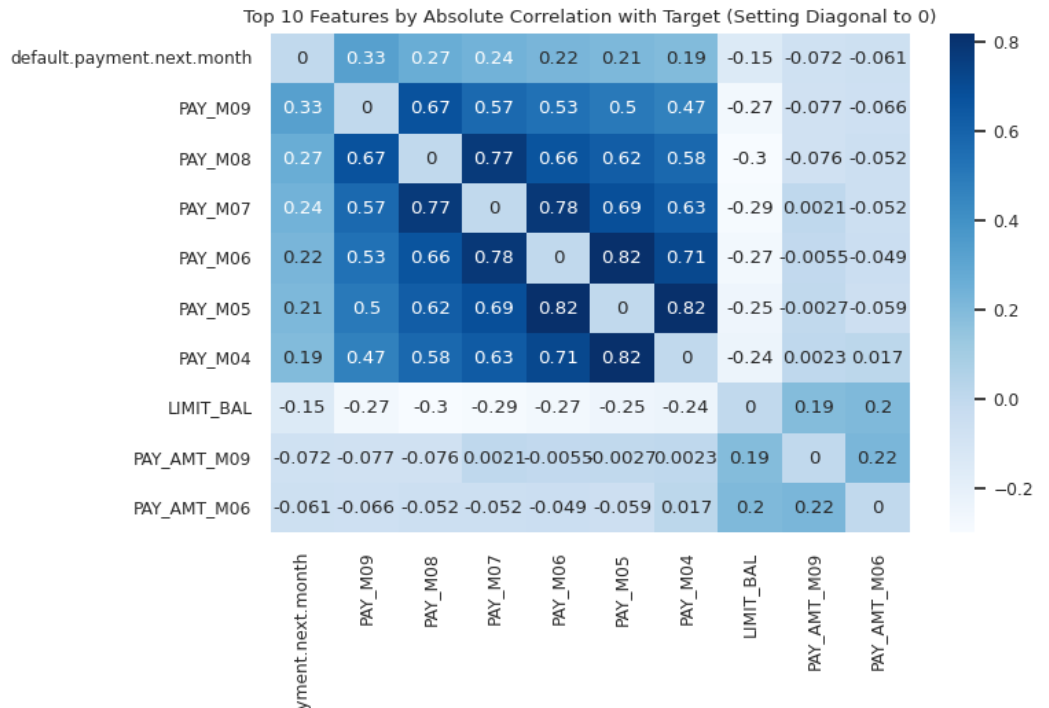

**Insight:** Recent performances are great predictors, and they are highly correlated with one-another (and likely with education/age/marriage/etc also). We will choose a model that can deal with multicolinearity.

**Visualization 2:** 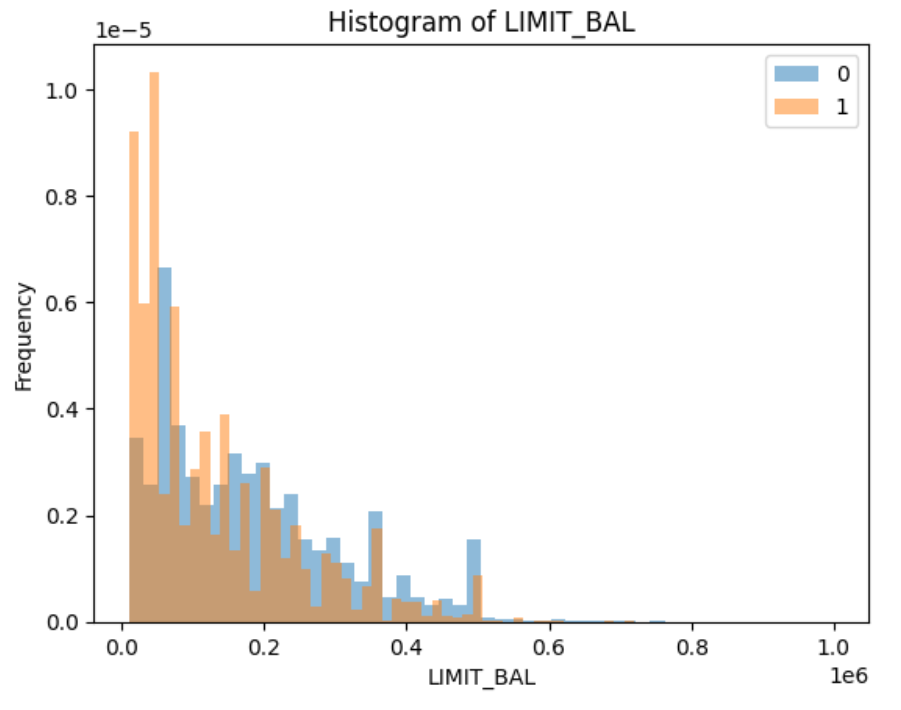

**Insight:** We would expect that credit limit is a good stand-in for "financial success and experience," and that seems to hold here (as it predicts defaults well).

#### Evaluation metric

I will use accuracy as the main evaluation metric. The dataset is moderately imbalanced, but not extremely imbalanced: about 77.7% of the training examples are no-default and about 22.3% are default. Accuracy is therefore a reasonable simple metric for this assignment, especially because it lets us compare all models consistently. However, in a real credit-default setting, I would also want to examine precision, recall, and threshold choices because false positives and false negatives may have different costs.

In [5]:
train_df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_M04,BILL_AMT_M04,PAY_AMT_M04,PAY_M05,...,PAY_M07,BILL_AMT_M07,PAY_AMT_M07,PAY_M08,BILL_AMT_M08,PAY_AMT_M08,PAY_M09,BILL_AMT_M09,PAY_AMT_M09,default.payment.next.month
16395,16396,320000.0,2,1,2,36,0,3788.0,7013.0,0,...,0,28695.0,1000.0,0,28179.0,5018.0,0,29026.0,5000.0,0
21448,21449,440000.0,2,1,2,30,0,117870.0,51663.0,0,...,-1,87426.0,130007.0,-1,612.0,87426.0,-1,777.0,612.0,0
20034,20035,160000.0,2,3,1,44,-2,-18.0,0.0,-2,...,-2,-18.0,0.0,-2,-18.0,0.0,-2,-18.0,0.0,0
25755,25756,120000.0,2,2,1,30,0,47379.0,1702.0,0,...,0,104694.0,4204.0,0,102860.0,5502.0,0,101596.0,3706.0,0
1438,1439,50000.0,1,2,2,54,0,27380.0,1500.0,0,...,0,27168.0,1200.0,2,46885.0,1400.0,1,48153.0,0.0,0


In [6]:
train_df.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
ID,21000.0,14962.348238,8650.734050,1.0,7498.75,14960.5,22458.25,30000.0
LIMIT_BAL,21000.0,167880.651429,130202.682167,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,21000.0,1.600762,0.489753,1.0,1.00,2.0,2.00,2.0
EDUCATION,21000.0,1.852143,0.792961,0.0,1.00,2.0,2.00,6.0
MARRIAGE,21000.0,1.554000,0.521675,0.0,1.00,2.0,2.00,3.0
AGE,21000.0,35.500810,9.212644,21.0,28.00,34.0,41.00,79.0
PAY_M04,21000.0,-0.295095,1.147992,-2.0,-1.00,0.0,0.00,8.0
BILL_AMT_M04,21000.0,38767.202667,59587.689549,-339603.0,1215.75,16854.5,49253.75,961664.0
PAY_AMT_M04,21000.0,5237.762190,18116.846563,0.0,110.75,1500.0,4000.00,528666.0
PAY_M05,21000.0,-0.264429,1.137205,-2.0,-1.00,0.0,0.00,8.0


In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21000 entries, 16395 to 19966
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          21000 non-null  int64  
 1   LIMIT_BAL                   21000 non-null  float64
 2   SEX                         21000 non-null  int64  
 3   EDUCATION                   21000 non-null  int64  
 4   MARRIAGE                    21000 non-null  int64  
 5   AGE                         21000 non-null  int64  
 6   PAY_M04                     21000 non-null  int64  
 7   BILL_AMT_M04                21000 non-null  float64
 8   PAY_AMT_M04                 21000 non-null  float64
 9   PAY_M05                     21000 non-null  int64  
 10  BILL_AMT_M05                21000 non-null  float64
 11  PAY_AMT_M05                 21000 non-null  float64
 12  PAY_M06                     21000 non-null  int64  
 13  BILL_AMT_M06                2100

In [8]:
train_df.isnull().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_M04                       0
BILL_AMT_M04                  0
PAY_AMT_M04                   0
PAY_M05                       0
BILL_AMT_M05                  0
PAY_AMT_M05                   0
PAY_M06                       0
BILL_AMT_M06                  0
PAY_AMT_M06                   0
PAY_M07                       0
BILL_AMT_M07                  0
PAY_AMT_M07                   0
PAY_M08                       0
BILL_AMT_M08                  0
PAY_AMT_M08                   0
PAY_M09                       0
BILL_AMT_M09                  0
PAY_AMT_M09                   0
default.payment.next.month    0
dtype: int64

In [9]:
train_df.nunique()

ID                            21000
LIMIT_BAL                        80
SEX                               2
EDUCATION                         7
MARRIAGE                          4
AGE                              56
PAY_M04                          10
BILL_AMT_M04                  15127
PAY_AMT_M04                    5536
PAY_M05                          10
BILL_AMT_M05                  15383
PAY_AMT_M05                    5533
PAY_M06                          11
BILL_AMT_M06                  15756
PAY_AMT_M06                    5541
PAY_M07                          11
BILL_AMT_M07                  16116
PAY_AMT_M07                    6048
PAY_M08                          11
BILL_AMT_M08                  16325
PAY_AMT_M08                    6381
PAY_M09                          11
BILL_AMT_M09                  16613
PAY_AMT_M09                    6330
default.payment.next.month        2
dtype: int64

In [10]:
train_df["EDUCATION"].value_counts(), train_df["MARRIAGE"].value_counts()

(EDUCATION
 2    9815
 1    7433
 3    3416
 5     210
 4      81
 6      35
 0      10
 Name: count, dtype: int64,
 MARRIAGE
 2    11210
 1     9527
 3      229
 0       34
 Name: count, dtype: int64)

In [11]:
train_df["default.payment.next.month"].value_counts(normalize=True)

default.payment.next.month
0    0.776762
1    0.223238
Name: proportion, dtype: float64

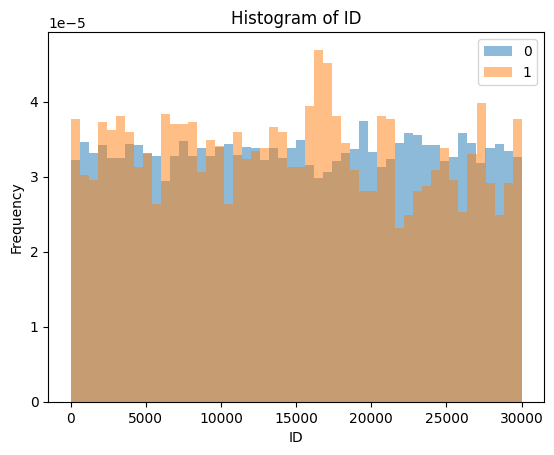

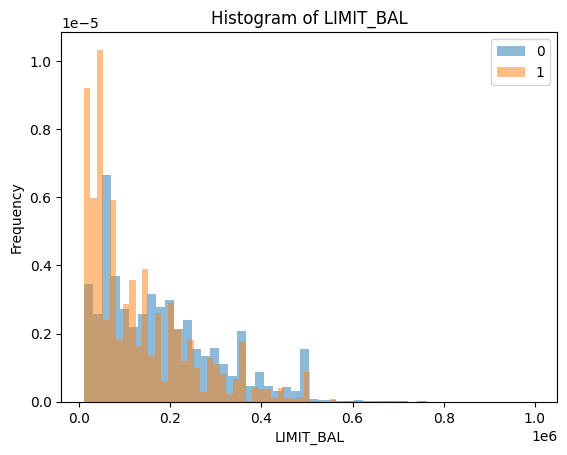

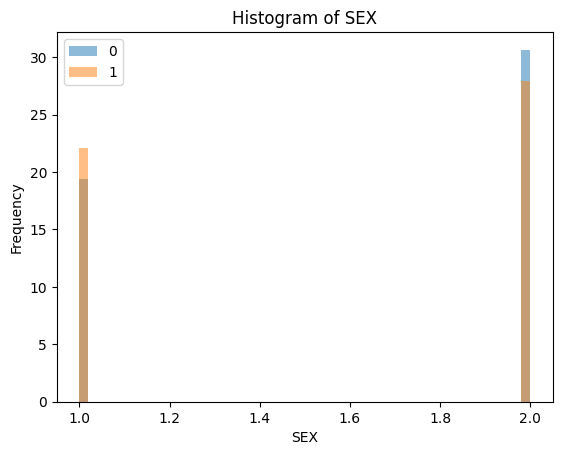

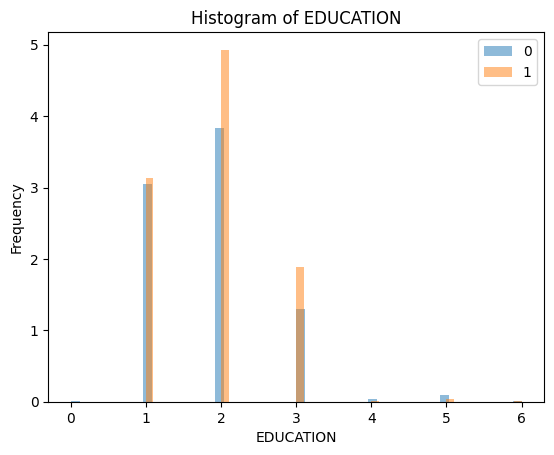

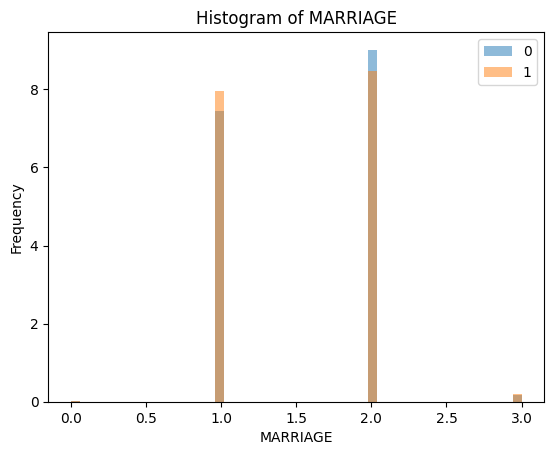

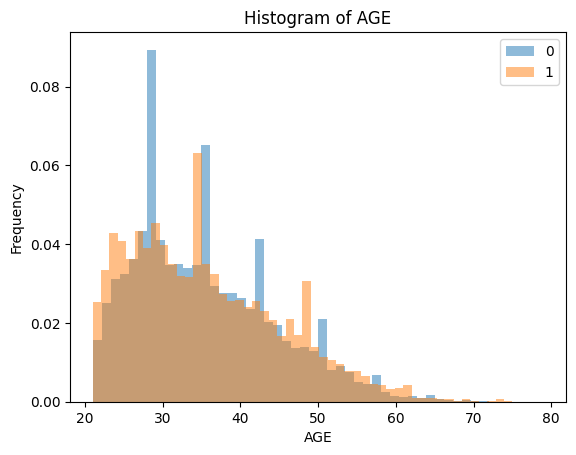

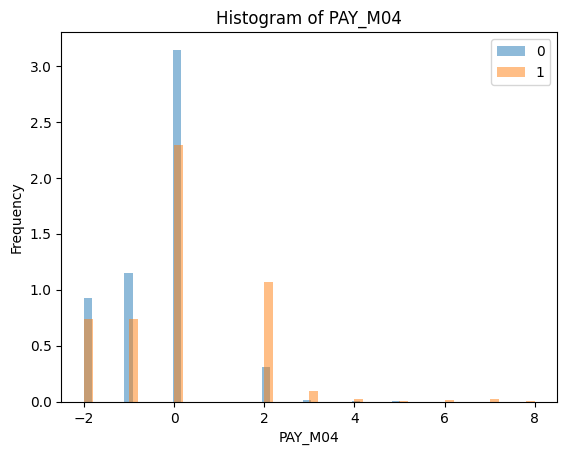

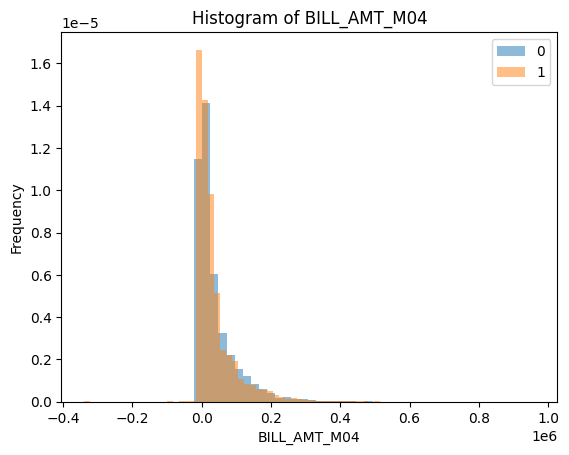

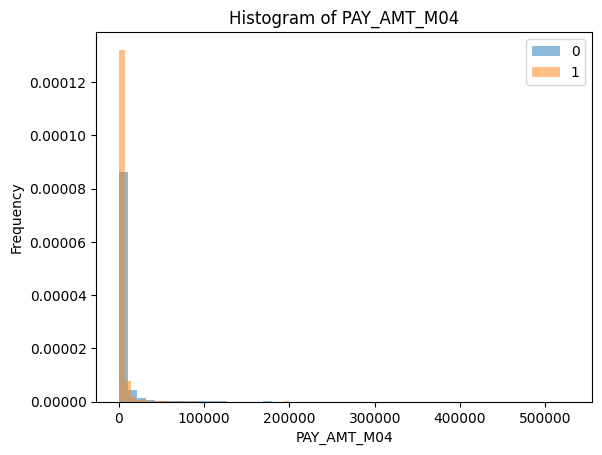

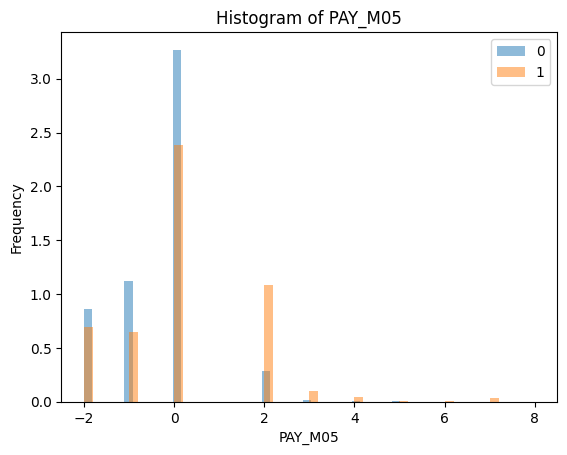

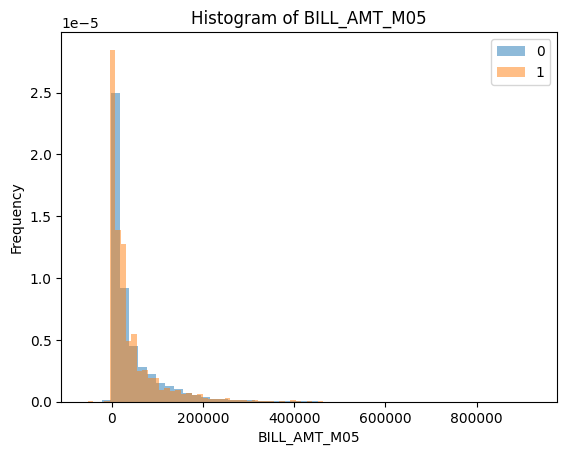

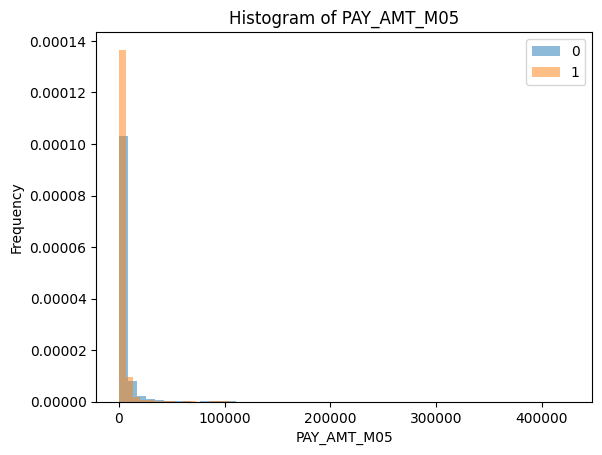

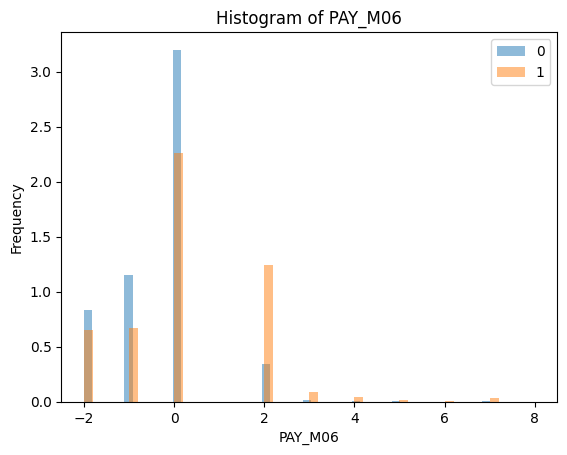

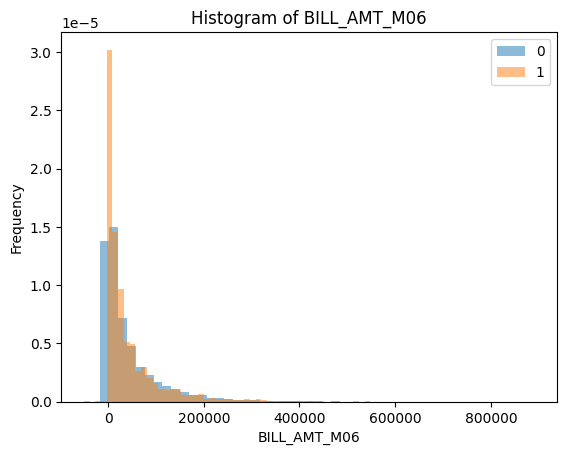

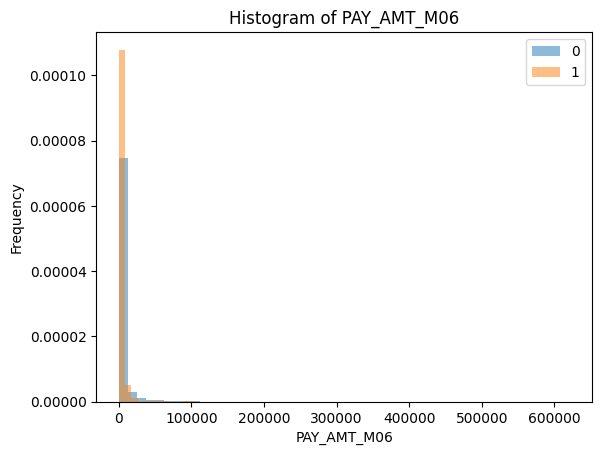

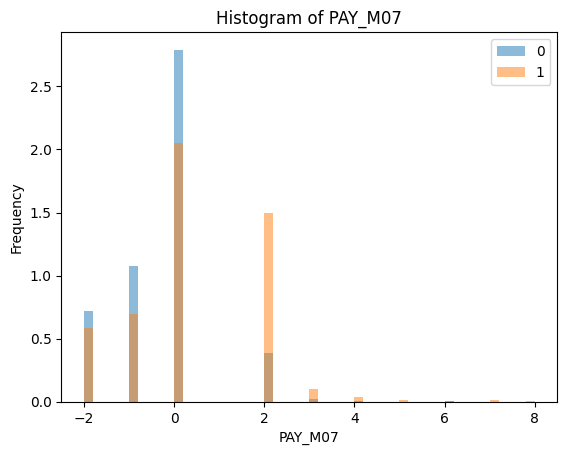

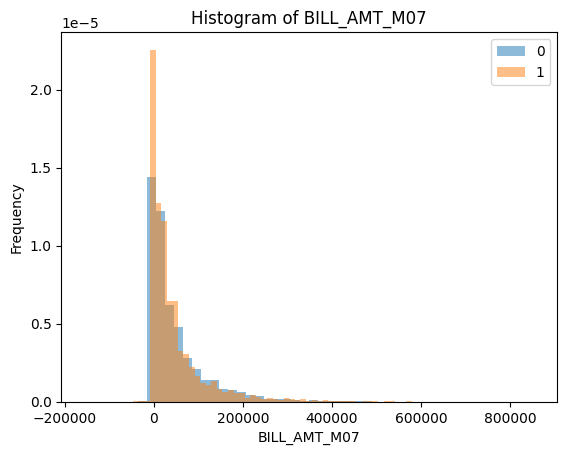

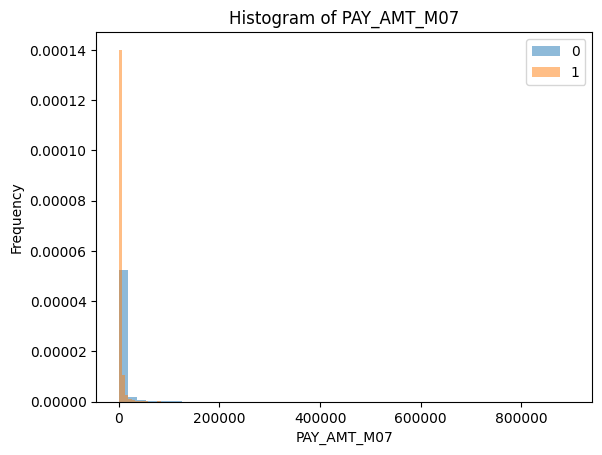

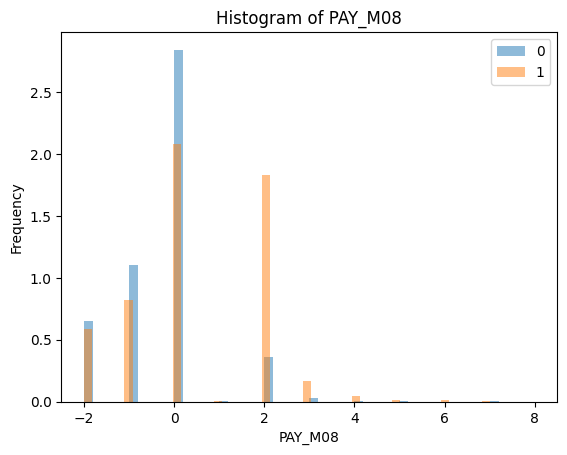

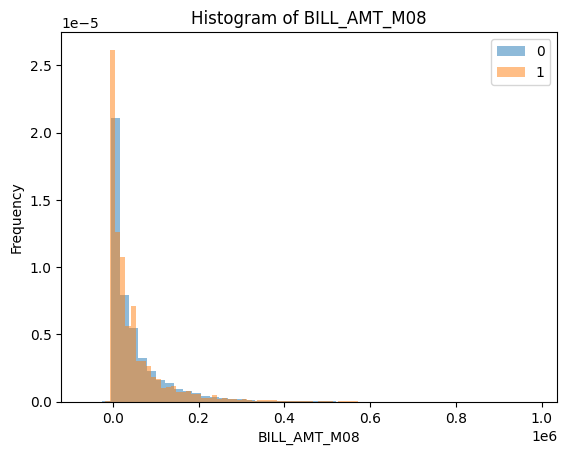

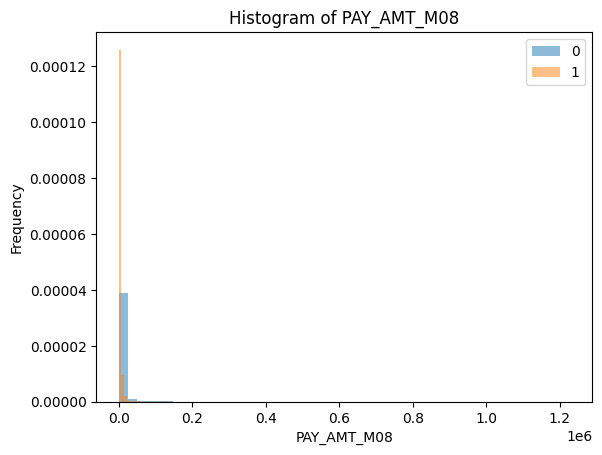

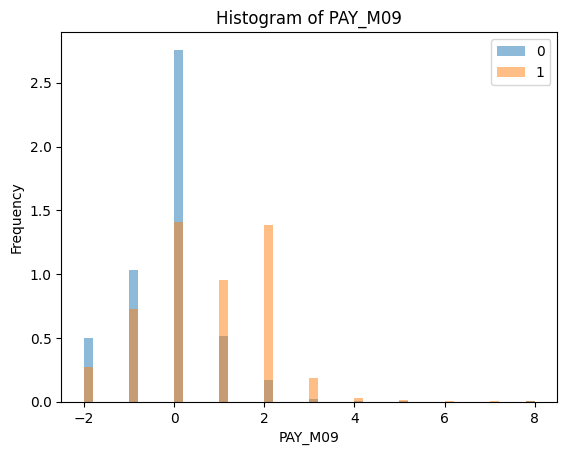

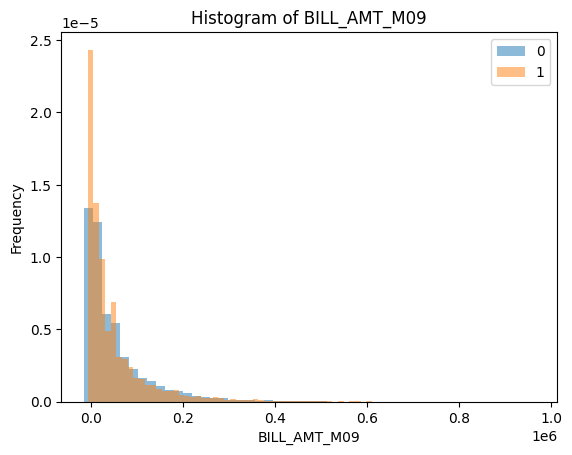

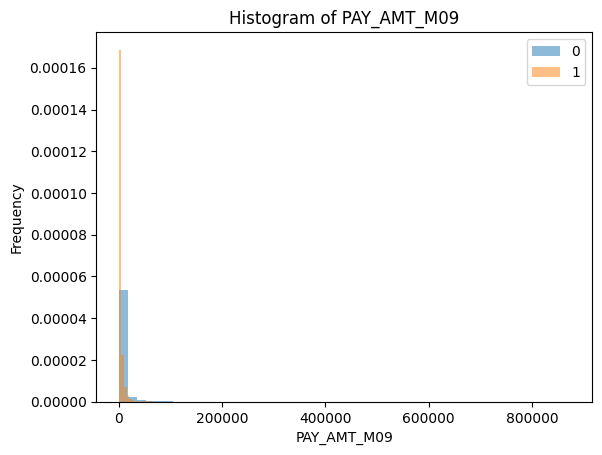

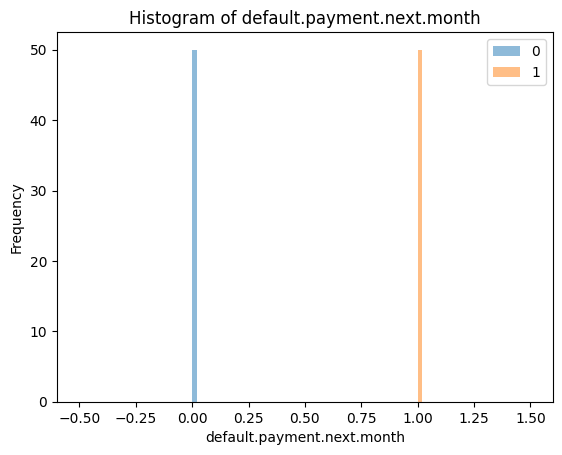

In [12]:
numeric_cols = train_df.describe(include="all").select_dtypes(include="number").columns.to_list()

for feat in numeric_cols:
    train_df.groupby("default.payment.next.month")[feat].plot.hist(bins=50, alpha=0.5, legend=True, density = True, title = "Histogram of " + feat)
    plt.xlabel(feat)
    plt.show()

In [13]:
train_df.corr()["default.payment.next.month"].sort_values()

LIMIT_BAL                    -0.149247
PAY_AMT_M09                  -0.071563
PAY_AMT_M06                  -0.061005
PAY_AMT_M07                  -0.060868
PAY_AMT_M08                  -0.060730
PAY_AMT_M04                  -0.056093
PAY_AMT_M05                  -0.050943
SEX                          -0.046320
MARRIAGE                     -0.021735
BILL_AMT_M09                 -0.020632
ID                           -0.017861
BILL_AMT_M08                 -0.015301
BILL_AMT_M07                 -0.014718
BILL_AMT_M06                 -0.012313
BILL_AMT_M05                 -0.007868
BILL_AMT_M04                 -0.004944
AGE                           0.010715
EDUCATION                     0.026558
PAY_M04                       0.194787
PAY_M05                       0.208726
PAY_M06                       0.219692
PAY_M07                       0.240503
PAY_M08                       0.265160
PAY_M09                       0.325102
default.payment.next.month    1.000000
Name: default.payment.nex

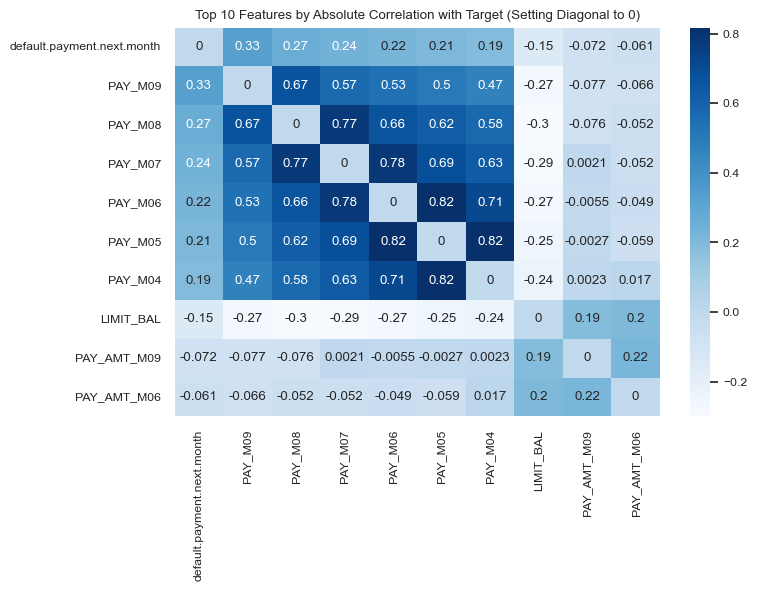

In [14]:
corr = train_df.corr()
target_corr = corr["default.payment.next.month"].abs().sort_values(ascending=False)
top_features = target_corr.index[:10]  # top 10 most correlated features

cor_sorted = corr.loc[top_features, top_features]

# Zero out diagonal using pandas instead of numpy
cor_sorted = cor_sorted - np.eye(len(cor_sorted)) * np.diag(cor_sorted.values)

plt.figure(figsize=(8, 6))
sns.set(font_scale=0.8)
sns.heatmap(cor_sorted, annot=True, cmap=plt.cm.Blues)
plt.title("Top 10 Features by Absolute Correlation with Target (Setting Diagonal to 0)")
plt.tight_layout()
plt.show()


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 4. Feature engineering
<hr>
Our EDA showed several features were ordinally encoded in a strange way. We'll need to fix these with new binary features.

Let's also add a few other sensible features that, based on our real-world intuition, may be useful.
   
</div>

**Features to be added:**
* **EDUCATION_IS_OTHER**: Binary feature. 1 if education was originally 4 ("other"), 0 otherwise. See EDA for details.
* **NO_ACTIVITY_M04-NO_ACTIVITY_M09**: Binary feature. 1 if the user had no activity in that month. See EDA for details.
* **REVOLVING_PAYMENT_M04-REVOLVING_PAYMENT_M09**: Binary feature. 1 if the user used revolving credit to pay in that month. See EDA for details.
* **TOTAL_LATES**: Numeric feature. The number of payment statuses > 0. Being consistently late is a better indicator of default than being late in any particular month.
* **LARGEST_LATE_STREAK**: Numeric feature. The maximum of previous payment statuses. Very bad prior streaks may indicate financially unstable individual.
* **SMALLEST_LATE_STREAK**: Numeric feature. The minimum of previous payment statuses. An individual doesn't have even 1 month on time or close to on time is more likely to default.
* **BILL_TO_PAYMENT_RATIO**: The ratio of this month's PAY_AMT_MXX (previous payment) to last month's bill BILL_AMT_M05 (the amount that was due at time of previous payment). A payment of 100,000 is good if you owed 100,000 last month, but terrible if you owed 1,000,000 last month.

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 5. Preprocessing and transformations
<hr>
We'll need to define our feature types and create a column transformer + pipeline combo to preprocess the data.
</div>

In [15]:
# Add feature engineered columns mentioned in part 4.
# Used Gemini to get inspiration for the syntax.
# Does not leak information from validation set if performed before CV (no per-column actions)
def add_features(X):
    df = X.copy()

    pay_status_cols = ['PAY_M04', 'PAY_M05', 'PAY_M06', 'PAY_M07', 'PAY_M08', 'PAY_M09']
    months = list(range(4, 10))

    # EDUCATION_IS_OTHER is 1 if education was originally 4.
    df['EDUCATION_IS_OTHER'] = (df['EDUCATION'] == 4).astype(int)

    # TOTAL_LATES is how many times the customer was late.
    df['TOTAL_LATES'] = (df[pay_status_cols] > 0).sum(axis=1)

    # SMALLEST/LARGEST_LATE_STREAK is the min/max of previous payment statuses.
    df['LARGEST_LATE_STREAK'] = df[pay_status_cols].max(axis=1)
    df['SMALLEST_LATE_STREAK'] = df[pay_status_cols].min(axis=1).clip(lower=0) # Negative values are present in data at this stage, but won't make sense for this.

    # NO_ACTIVITY_MXX measures if user's payment status was -2 originally.
    # REVOLVING_PAYMENT_MXX measures if user's payment status was 0 originally.
    # BILL_TO_PAYMENT_RATIO_MXX is the ratio of this months payment (toward previous bill) to previous bill.
    for month in months:
        df['NO_ACTIVITY_M0' + str(month)] = (df['PAY_M0' + str(month)] == -2).astype(int)
        df['REVOLVING_PAYMENT_M0' + str(month)] = (df['PAY_M0' + str(month)] == 0).astype(int)
        if month != min(months):
            df['BILL_TO_PAYMENT_RATIO_M0' + str(month)] = np.where(
                df['BILL_AMT_M0' + str(month - 1)] == 0,
                1,
                df['PAY_AMT_M0' + str(month)] / df['BILL_AMT_M0' + str(month - 1)]
            )
        else:
            # Data is not available for bill amount of month "min - 1", so assume perfect payment on month "min".
            # Months far into the past are not great predictors, so this is unlikely to derail the model significantly.
            df['BILL_TO_PAYMENT_RATIO_M0' + str(month)] = 1 
        
    return df

In [16]:
pay_feats = [
    "PAY_M04",
    "PAY_M05",
    "PAY_M06",
    "PAY_M07",
    "PAY_M08",
    "PAY_M09",
] # Set -2 and -1 to 0. Then, scale.
pay_feats_pipe = make_pipeline(
    FunctionTransformer(
        lambda x: np.where(#This syntax inspired by Gemini 
            (x == -1) | (x == -2), 
            0,
            x
        )
    , feature_names_out="one-to-one"),
    StandardScaler()
)

# "AGE" --> Cap at 65 then scale
age_feat_pipe = make_pipeline(
    FunctionTransformer(
        lambda x: np.where(
            (x > 65),
            65,
            x
        )
    , feature_names_out="one-to-one"),
    StandardScaler()
)
    

other_numeric_feats = [
    "LIMIT_BAL",
    "BILL_AMT_M04",
    "PAY_AMT_M04",
    "BILL_AMT_M05",
    "PAY_AMT_M05",
    "BILL_AMT_M06",
    "PAY_AMT_M06",
    "BILL_AMT_M07",
    "PAY_AMT_M07",
    "BILL_AMT_M08",
    "PAY_AMT_M08",
    "BILL_AMT_M09",
    "PAY_AMT_M09",
    "LARGEST_LATE_STREAK",
    "SMALLEST_LATE_STREAK",
    "BILL_TO_PAYMENT_RATIO_M04",
    "BILL_TO_PAYMENT_RATIO_M05",
    "BILL_TO_PAYMENT_RATIO_M06",
    "BILL_TO_PAYMENT_RATIO_M07",
    "BILL_TO_PAYMENT_RATIO_M08",
    "BILL_TO_PAYMENT_RATIO_M09",
    'TOTAL_LATES',
] # Scale
other_numeric_feats_pipe = make_pipeline(
    StandardScaler()
)

# "SEX" --> OHE, ignore unknown, drop if binary
sex_pipe = make_pipeline(
    OneHotEncoder(handle_unknown='ignore', drop="if_binary")
)

# "EDUCATION" --> impute with missing_values = 5, then 6, then 0.
# then, impute with missing_values = 4 (setting to 0)
random_constant = 67 # SIXTY SEVEN
education_pipe = make_pipeline(
    FunctionTransformer( #Inspired by Gemini. Make all unknowns one constant, then replace all at once.
        lambda x: np.where(
            (x == 5) | (x == 6) | (x == 0),
            random_constant,
            x
        )
    , feature_names_out="one-to-one"),
    SimpleImputer(missing_values=67, strategy='most_frequent'),
    SimpleImputer(missing_values=4, strategy='constant', fill_value=0),
    StandardScaler()
)

# "MARRIAGE" --> impute 0, then OHE, ignore unknown, drop if binary
marriage_pipe = make_pipeline(
    SimpleImputer(missing_values=0, strategy="most_frequent"),
    OneHotEncoder(handle_unknown='ignore', drop="if_binary"),
)

drop_feats = ["ID"]

target_column = "default.payment.next.month"

In [17]:
column_transformer = make_column_transformer(
    (pay_feats_pipe, pay_feats),
    (age_feat_pipe, ["AGE"]),
    (other_numeric_feats_pipe, other_numeric_feats),
    (sex_pipe, ["SEX"]),
    (education_pipe, ["EDUCATION"]),
    (marriage_pipe, ["MARRIAGE"]),
    ("drop", drop_feats),
    remainder="passthrough",
)
column_transformer

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('pipeline-1', ...), ('pipeline-2', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` an

In [18]:
feature_adder = FunctionTransformer(add_features, validate=False)
feature_adder

,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function add...001F2FE2AF380>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to func... versionadded:: 0.18",None
,"inv_kw_args inv_kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to inverse_func... versionadded:: 0.18",None


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 6. Baseline model
<hr>
Let's use dummy classifier as our baseline.
</div>

### Baseline Results
* Baseline has 77.7% mean validation accuracy consistently. The bar will be higher for our models.
* Baseline accuracy is approximately the percentage of non-default targets, as expected.

In [19]:
dummy = DummyClassifier()
dummy_pipe = make_pipeline(
    feature_adder,
    column_transformer,
    dummy
)
# X_train = add_features(X_train)
dummy_scores = cross_validate(dummy_pipe, X_train, y_train, return_train_score=True, n_jobs=-1)
dummy_df = pd.DataFrame(dummy_scores)
dummy_df

,fit_time,score_time,test_score,train_score
0,0.162842,0.064632,0.776905,0.776726
1,0.154330,0.052282,0.776905,0.776726
2,0.150532,0.062061,0.776667,0.776786
3,0.150544,0.062941,0.776667,0.776786
4,0.152990,0.061415,0.776667,0.776786


In [20]:
dummy_df.mean()

fit_time       0.154247
score_time     0.060666
test_score     0.776762
train_score    0.776762
dtype: float64

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 7. Linear models 
<hr>
Since preprocessing is done, and we say strong linear relationships in our EDA, let's use a linear model as our first real attempt at the problem.
</div>

### Findings
* With default hyperparameters, the model had a validation accuracy of 81.77%. This is only 4% higher than the baseline.
* With the best hyperparameters (C=0.1), the model had a validation accuracy of 81.81%, with deviation 0.36%.
* Since many hyperparameter choices had validation accuracies within 1-2 standard deviations of the best hyperparameter, it seems hyperparameter choice has only a mild impact for this model.
* It is strange that this model doesn't perform much better than the baseline. Perhaps our data is simply difficult to classify, or perhaps the other models will do better. However, logistic regression has no obvious weaknesses to this kind of data, and in fact should perform well with such multi-dimensional data. This does not bode well for future models...

In [21]:
# Let's just see what the base model is capable of
linear = LogisticRegression()
linear_pipe = make_pipeline(feature_adder, column_transformer, linear)
linear_scores = cross_validate(linear_pipe, X_train, y_train, return_train_score=True, n_jobs=-1)
linear_df = pd.DataFrame(linear_scores)
linear_df

,fit_time,score_time,test_score,train_score
0,0.507096,0.064936,0.814762,0.819345
1,0.522066,0.064873,0.817143,0.817857
2,0.532835,0.059844,0.821905,0.816845
3,0.500888,0.057443,0.820714,0.817083
4,0.403648,0.051315,0.814048,0.818155


In [22]:
linear_df.mean()

fit_time       0.493307
score_time     0.059682
test_score     0.817714
train_score    0.817857
dtype: float64

In [23]:
param_grid = {
    "logisticregression__C": [0.001, 0.01, 0.1, 1.0, 10, 100],
}

search = GridSearchCV(
    linear_pipe, 
    param_grid = param_grid, 
    n_jobs=-1, 
    return_train_score=True
)
search.fit(X_train, y_train)
results = pd.DataFrame(search.cv_results_)
results.T

,0,1,2,3,4,5
mean_fit_time,0.226806,0.531712,0.732625,0.843568,0.817972,0.637635
std_fit_time,0.096978,0.020099,0.02309,0.026877,0.093564,0.039861
mean_score_time,0.059107,0.161477,0.133404,0.140415,0.155817,0.087145
std_score_time,0.019915,0.008495,0.019539,0.007585,0.031963,0.007597
param_logisticregression__C,0.001,0.01,0.1,1.0,10.0,100.0
params,{'logisticregression__C': 0.001},{'logisticregression__C': 0.01},{'logisticregression__C': 0.1},{'logisticregression__C': 1.0},{'logisticregression__C': 10},{'logisticregression__C': 100}
split0_test_score,0.810952,0.814286,0.814524,0.814762,0.814286,0.814286
split1_test_score,0.809048,0.81619,0.816667,0.817143,0.817143,0.816905
split2_test_score,0.81381,0.819524,0.823095,0.821905,0.821905,0.822381
split3_test_score,0.812143,0.821667,0.821667,0.820714,0.820476,0.820476


In [24]:
best_C = search.best_params_
best_C 

{'logisticregression__C': 0.1}

In [25]:
linear = LogisticRegression(C=0.1)
linear_pipe = make_pipeline(feature_adder, column_transformer, linear)

linear_scores = cross_validate(linear_pipe, X_train, y_train, return_train_score=True, n_jobs=-1)

In [26]:
linear_scores

{'fit_time': array([0.33922601, 0.37176013, 0.34532094, 0.42149591, 0.33338475]),
 'score_time': array([0.06668139, 0.05817986, 0.07096052, 0.05753827, 0.06552815]),
 'test_score': array([0.81452381, 0.81666667, 0.82309524, 0.82166667, 0.8147619 ]),
 'train_score': array([0.82029762, 0.81785714, 0.81738095, 0.81720238, 0.81845238])}

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 8. Different models
<hr>
Our linear model underperformed. Let's see what other models can do.
</div>

### Findings
* The decision tree is massively overfitting. Its train score is basically perfect at 99.9%, but the validation score is only 72.3%. This is even worse than logistic regression, and is a classic example of a default decision tree memorizing the training data.
* KNN does not overfit as badly, but its validation score is only 79.5%, which is worse than logistic regression. It also has by far the slowest scoring time, which makes sense because KNN has to compare new examples with many training examples at prediction time.
* Random forest also has a near-perfect train score, which suggests overfitting. However, its validation score is much better than the single decision tree. This makes sense because random forests average many trees and are usually more stable than a single tree.
* Gradient boosting performed the best in this section, with validation accuracy around 82.0%. Its train score is only slightly higher than its validation score, so it seems to be controlling overfitting better than the decision tree, random forest, and XGBoost.
* XGBoost also performs reasonably well, but it has a much larger gap between train and validation scores than gradient boosting. This suggests it is overfitting more.
* In terms of fit time, gradient boosting was the slowest model to fit. Random forest was also relatively slow. XGBoost was surprisingly fast here, and KNN was very fast to fit but slow to score.

### Conclusion
* The only model that clearly beats logistic regression in this section is gradient boosting, but only by a tiny amount.
* Logistic regression got about 81.8% validation accuracy, while gradient boosting got about 82.0%.
* This is a bit surprising. We expected the more flexible tree-based ensemble models to do much better. Instead, most models seem to get stuck around the same score.
* My guess is that the dataset is just difficult to classify from these features.
* For now, gradient boosting looks like the strongest model from this section because it has the best validation score and the smallest train-validation gap among the non-linear models.
* Something to remember is that these models are using the default hyperparameters, it is likely that their scores will go up as the hyperparameters become better optimized.

In [27]:
def mean_std_cross_val_scores(model, X_train, y_train, **kwargs):
    """
    Returns mean and std of cross validation

    Parameters
    ----------
    model :
        scikit-learn model
    X_train : numpy array or pandas DataFrame
        X in the training data
    y_train :
        y in the training data

    Returns
    ----------
        pandas Series with mean scores from cross_validation
    """

    scores = cross_validate(model, X_train, y_train, **kwargs)

    mean_scores = pd.DataFrame(scores).mean()
    std_scores = pd.DataFrame(scores).std()
    out_col = []

    for i in range(len(mean_scores)):
        out_col.append((f"%0.3f (+/- %0.3f)" % (mean_scores.iloc[i], std_scores.iloc[i])))

    return pd.Series(data=out_col, index=mean_scores.index)

In [28]:
classifiers  = {
    "dummy": dummy_pipe,
    "logistic_regression": linear_pipe,
    "decision_tree": make_pipeline(feature_adder, column_transformer, DecisionTreeClassifier(random_state=123)),
    "k_neighbours": make_pipeline(feature_adder, column_transformer, KNeighborsClassifier()),
    "random_forest": make_pipeline(feature_adder, column_transformer, RandomForestClassifier(random_state=123)),
    "gradient_boosting": make_pipeline(feature_adder, column_transformer, GradientBoostingClassifier(random_state=123)),
    "xgboost": make_pipeline(feature_adder, column_transformer, XGBClassifier(random_state=123)),
}

In [29]:
results = {}
scoring_metric = "accuracy"
for (name, model) in classifiers.items():
    results[name] = mean_std_cross_val_scores(
        model, X_train, y_train, return_train_score=True, scoring=scoring_metric
    )
    # print(f"{name}:\n{results[name]}\n\n")
pd.DataFrame(results).T

,fit_time,score_time,test_score,train_score
dummy,0.096 (+/- 0.013),0.041 (+/- 0.004),0.777 (+/- 0.000),0.777 (+/- 0.000)
logistic_regression,0.269 (+/- 0.037),0.045 (+/- 0.013),0.818 (+/- 0.004),0.818 (+/- 0.001)
decision_tree,0.780 (+/- 0.245),0.094 (+/- 0.120),0.723 (+/- 0.003),0.999 (+/- 0.000)
k_neighbours,0.074 (+/- 0.018),0.507 (+/- 0.787),0.795 (+/- 0.005),0.844 (+/- 0.002)
random_forest,6.157 (+/- 0.521),0.154 (+/- 0.035),0.814 (+/- 0.007),0.999 (+/- 0.000)
gradient_boosting,14.656 (+/- 0.472),0.067 (+/- 0.018),0.820 (+/- 0.006),0.828 (+/- 0.002)
xgboost,0.397 (+/- 0.142),0.034 (+/- 0.002),0.810 (+/- 0.007),0.915 (+/- 0.003)


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 9. Feature selection 
<hr>
I wonder if feature selection helps any of the models?
</div>

### Findings
* The model decided to keep pay status for month 9, pay amount for month 8, total lates, the revolving payment flag for months 8 and 9, and whether education is other.
* Pay statuses and amounts of most recent months make sense, and are likely great predictors of future defaults.
* Revolving payment in recent months may signal someone who is under financial burden and is about to go under. Makes sense.
* The total number of late payments makes sense, as someone who's had many late payments is more likely to have another.
* It is strange that the model considers "education == other" as one of the 6 most important indicators. Perhaps many "other" educated persons defaulted? Let's check:

In [30]:
X_engineered_for_part_9_findings = add_features(X_train) # Code generated by Gemini
other_edu_mask = X_engineered_for_part_9_findings['EDUCATION_IS_OTHER'] == 1
defaults_in_other = y_train[other_edu_mask]
default_rate_other = defaults_in_other.mean()
default_rate_other

np.float64(0.06172839506172839)

### Findings continued
* Interesting! Those with an "other" education had a default rate almost 75% lower than most! Makes sense that the model considers this important.
  * Thank goodness we didn't impute "other"!
* It's reasonable that the model kept only the most recent months. Whether someone was late on their last/second last payment says a lot about the next one. Whether they were late 6 months ago likely doesn't add any information that the total number of lates doesn't contain.
* Since this step is being performed before hyperparameter optimization, the model is using default hyperparameters. The model is clearly overfitting (test_score 80%, train_score 95%). It may be benefitial to iterate between feature selection and hyperparameter optimization. However, we are nearing the limit of this project's scope, and the chosen features seem reasonable.
* All models are taking drastically longer to fit and train on the REDUCED feature set. This is because RFECV itself is expensive. Since train/score times are not relevant for this project, we will intentionally not bother fixing this.
* Random forest and decision tree had much lower train scores after feature selection, so feature selection reduced overfitting. However, it did not eliminate overfitting completely, especially for the decision tree. This didn't happen to other models. *This was pointed out to us by AI*.
* Decision Tree was the only model to do significantly better on the reduced dataset. This is likely because a DT with default depth overfits significantly, and our reduced set limited its ability to do so.

### Conclusion
* We will not keep feature selection, as the limited feature set did not significantly alter performance of our top models. Furthermore, dimensionality is not a problem for our top models, and train/prediction times are not of concern either.

In [31]:
rfe_rf_pipe = make_pipeline(
    feature_adder,
    column_transformer,
    RFECV(
        LogisticRegression(max_iter=1000),
        cv=5,
        n_jobs=-1
    ),
    RandomForestClassifier(random_state=123)
)

rfe_scores = cross_validate(
    rfe_rf_pipe,
    X_train,
    y_train,
    return_train_score=True,
    scoring="accuracy",
    n_jobs=-1
)

pd.DataFrame(rfe_scores).mean()

fit_time       35.764023
score_time      0.194037
test_score      0.804476
train_score     0.954905
dtype: float64

In [32]:
rfe_rf_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('functiontransformer', ...), ('columntransformer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function add...001F2FE2AF380>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional ke

In [33]:
rfecv_step = rfe_rf_pipe.named_steps["rfecv"]

ct_features = rfe_rf_pipe.named_steps["columntransformer"].get_feature_names_out()

pd.DataFrame({
    "feature": ct_features,
    "ranking": rfecv_step.ranking_,
    "selected": rfecv_step.support_
}).sort_values("ranking")

,feature,ranking,selected
5,pipeline-1__PAY_M09,1,True
17,pipeline-3__PAY_AMT_M08,1,True
28,pipeline-3__TOTAL_LATES,1,True
34,remainder__EDUCATION_IS_OTHER,1,True
46,remainder__REVOLVING_PAYMENT_M09,1,True
44,remainder__REVOLVING_PAYMENT_M08,1,True
37,remainder__NO_ACTIVITY_M05,2,False
20,pipeline-3__LARGEST_LATE_STREAK,3,False
7,pipeline-3__LIMIT_BAL,4,False
43,remainder__NO_ACTIVITY_M08,5,False


In [34]:
naked_models = {
    "logistic_regression": LogisticRegression(C=0.1),
    "decision_tree": DecisionTreeClassifier(random_state=123),
    "k_neighbours": KNeighborsClassifier(),
    "random_forest": RandomForestClassifier(random_state=123),
    "gradient_boosting": GradientBoostingClassifier(random_state=123),
    "xgboost": XGBClassifier(random_state=123),
}

results_after = {}
scoring_metric = "accuracy"

for name, model in naked_models.items():
    pipe = make_pipeline(
        feature_adder,
        column_transformer,
        RFECV(
            LogisticRegression(max_iter=1000),
            cv=5,
            scoring=scoring_metric,
            n_jobs=-1,
        ),
        model,
    )

    results_after[name] = mean_std_cross_val_scores(
        pipe,
        X_train,
        y_train,
        return_train_score=True,
        scoring=scoring_metric,
        n_jobs=-1,
    )

In [35]:
before_df = pd.DataFrame(results).T
after_df = pd.DataFrame(results_after).T

display(before_df)
display(after_df)

,fit_time,score_time,test_score,train_score
dummy,0.096 (+/- 0.013),0.041 (+/- 0.004),0.777 (+/- 0.000),0.777 (+/- 0.000)
logistic_regression,0.269 (+/- 0.037),0.045 (+/- 0.013),0.818 (+/- 0.004),0.818 (+/- 0.001)
decision_tree,0.780 (+/- 0.245),0.094 (+/- 0.120),0.723 (+/- 0.003),0.999 (+/- 0.000)
k_neighbours,0.074 (+/- 0.018),0.507 (+/- 0.787),0.795 (+/- 0.005),0.844 (+/- 0.002)
random_forest,6.157 (+/- 0.521),0.154 (+/- 0.035),0.814 (+/- 0.007),0.999 (+/- 0.000)
gradient_boosting,14.656 (+/- 0.472),0.067 (+/- 0.018),0.820 (+/- 0.006),0.828 (+/- 0.002)
xgboost,0.397 (+/- 0.142),0.034 (+/- 0.002),0.810 (+/- 0.007),0.915 (+/- 0.003)


,fit_time,score_time,test_score,train_score
logistic_regression,29.551 (+/- 1.489),0.056 (+/- 0.019),0.817 (+/- 0.004),0.818 (+/- 0.002)
decision_tree,32.025 (+/- 1.451),0.058 (+/- 0.006),0.749 (+/- 0.035),0.955 (+/- 0.065)
k_neighbours,31.088 (+/- 2.410),0.661 (+/- 0.406),0.798 (+/- 0.007),0.839 (+/- 0.009)
random_forest,35.668 (+/- 1.464),0.180 (+/- 0.021),0.804 (+/- 0.011),0.955 (+/- 0.065)
gradient_boosting,35.677 (+/- 2.908),0.038 (+/- 0.008),0.819 (+/- 0.004),0.825 (+/- 0.002)
xgboost,31.380 (+/- 2.407),0.074 (+/- 0.011),0.810 (+/- 0.004),0.873 (+/- 0.031)


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 10. Hyperparameter optimization
<hr>
</div>

Note: Logistic regression is already fitted at C=0.1

### Findings
* **Logistic Regression**: Already discussed
* **DT:** The decision tree's performance increase is the largest. This makes sense. It exhibited clear signs of extreme overfitting before, which DTs with max_depth=None are prone too. A max_depth of 3 also seems reasonable: we would expect that much of the prediction can be made via the performance of just the past few months. Furthermore, this is in line with the fact that feature selection found only 6 features. Probably, splitting those features into different branches of the tree lets us reach great conclusions without further work.
* **KNN:** The KNN algorithm is doing slightly better with 18 neighbours than it did with 5. Logically, we would think 5 is too small of a number for this use case, so it makes sense.
* **RandomForest:** This model improved very slightly from optimization.
* **Boost models:** Gradient boosting did not improve much after tuning, but XGBoost improved noticeably, going from about 81.0% validation accuracy to about 82.1%. XGBoost ended up with the highest tuned validation score, although the difference between the top models is still very small.
* After optimization, the tuned decision tree performs almost as well as the stronger black-box ensemble models. This is useful because the decision tree is much easier to interpret, even though XGBoost has the highest validation score.

In [36]:
def run_grid_search(type, model, param_grid, X_train, y_train, scoring="accuracy"):
    pipe = make_pipeline(
        feature_adder,
        column_transformer,
        model
    )

    if type == "grid":
        search = GridSearchCV(
            pipe,
            param_grid=param_grid,
            cv=5,
            n_jobs=-1,
            return_train_score=True,
            scoring=scoring
        )
    elif type == "random":
        search = RandomizedSearchCV(
            pipe,
            param_distributions=param_grid,
            cv=5,
            n_jobs=-1,
            return_train_score=True,
            scoring=scoring,
            n_iter=10,
            random_state=123,
        )

    search.fit(X_train, y_train)
    return search

In [37]:
lr_param_grid = {
    "logisticregression__C": [0.001, 0.01, 0.1, 1.0, 10, 100],
}

lr_search = run_grid_search(
    "grid",
    LogisticRegression(),
    lr_param_grid,
    X_train,
    y_train
)

lr_search.best_params_, lr_search.best_score_

({'logisticregression__C': 0.1}, np.float64(0.8181428571428573))

In [38]:
dt_param_grid = {
    "decisiontreeclassifier__max_depth": np.arange(1, 10),
}

dt_search = run_grid_search(
    "grid",
    DecisionTreeClassifier(random_state=123),
    dt_param_grid,
    X_train,
    y_train
)

dt_search.best_params_, dt_search.best_score_

({'decisiontreeclassifier__max_depth': np.int64(3)},
 np.float64(0.8186666666666668))

In [39]:
knn_param_grid = {
    "kneighborsclassifier__n_neighbors": np.arange(1, 20),
}

knn_search = run_grid_search(
    "grid",
    KNeighborsClassifier(),
    knn_param_grid,
    X_train,
    y_train
)

knn_search.best_params_, knn_search.best_score_

({'kneighborsclassifier__n_neighbors': np.int64(18)},
 np.float64(0.8127142857142857))

In [40]:
rf_param_grid = {
    "randomforestclassifier__n_estimators": [10, 20, 50, 100, 200],
    "randomforestclassifier__max_depth": np.arange(1, 10),
}

rf_search = run_grid_search(
    "grid",
    RandomForestClassifier(random_state=123),
    rf_param_grid,
    X_train,
    y_train
)

rf_search.best_params_, rf_search.best_score_

({'randomforestclassifier__max_depth': np.int64(7),
  'randomforestclassifier__n_estimators': 200},
 np.float64(0.8194761904761905))

In [41]:
gb_param_grid = {
    "gradientboostingclassifier__n_estimators": [10, 20, 50, 100, 200],
    "gradientboostingclassifier__learning_rate": [0.01, 0.05, 0.1],
    "gradientboostingclassifier__max_depth": np.arange(1, 10),
}

gb_search = run_grid_search(
    "random",
    GradientBoostingClassifier(random_state=123),
    gb_param_grid,
    X_train,
    y_train
)

gb_search.best_params_, gb_search.best_score_

({'gradientboostingclassifier__n_estimators': 50,
  'gradientboostingclassifier__max_depth': np.int64(5),
  'gradientboostingclassifier__learning_rate': 0.1},
 np.float64(0.819095238095238))

In [42]:
xgb_param_grid = {
    "xgbclassifier__n_estimators": [10, 20, 50, 100, 200],
    "xgbclassifier__learning_rate": [0.01, 0.05, 0.1],
    "xgbclassifier__max_depth": np.arange(1, 10),
}

xgb_search = run_grid_search(
    "random",
    XGBClassifier(random_state=123),
    xgb_param_grid,
    X_train,
    y_train
)

xgb_search.best_params_, xgb_search.best_score_

({'xgbclassifier__n_estimators': 50,
  'xgbclassifier__max_depth': np.int64(5),
  'xgbclassifier__learning_rate': 0.1},
 np.float64(0.8207619047619048))

In [43]:
tuned_results = pd.DataFrame({
    "logistic_regression": {
        "best_cv_score": lr_search.best_score_,
        "best_params": lr_search.best_params_,
    },
    "decision_tree": {
        "best_cv_score": dt_search.best_score_,
        "best_params": dt_search.best_params_,
    },
    "k_neighbours": {
        "best_cv_score": knn_search.best_score_,
        "best_params": knn_search.best_params_,
    },
    "random_forest": {
        "best_cv_score": rf_search.best_score_,
        "best_params": rf_search.best_params_,
    },
    "gradient_boosting": {
        "best_cv_score": gb_search.best_score_,
        "best_params": gb_search.best_params_,
    },
    "xgboost": {
        "best_cv_score": xgb_search.best_score_,
        "best_params": xgb_search.best_params_,
    },
}).T

tuned_results

,best_cv_score,best_params
logistic_regression,0.818143,{'logisticregression__C': 0.1}
decision_tree,0.818667,{'decisiontreeclassifier__max_depth': 3}
k_neighbours,0.812714,{'kneighborsclassifier__n_neighbors': 18}
random_forest,0.819476,"{'randomforestclassifier__max_depth': 7, 'rand..."
gradient_boosting,0.819095,{'gradientboostingclassifier__n_estimators': 5...
xgboost,0.820762,"{'xgbclassifier__n_estimators': 50, 'xgbclassi..."


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 11. Interpretation and feature importances
<hr>
</div>

* The most important features of the random forest model were all payment statuses and the most recent payment amount.
* "High" values for payment status increased the model's likelihood of predicting "default," which makes sense, those who we've been later (especially by several months, especially recently) are more likely to default.
* Higher credit limits increased the model's confidence in the user's ability to pay. This is in line with what we predicted in our EDA: credit limit is likely a proxy for long-term financial responsibility. However, the model still considers long-term financial responsibility less important than the presence/absense of short-term financial strain (e.g. PAY_M09 > 0). Makes sense.
* The most important features (PAY_M09) were about 10 times more important than the moderate importance features (e.g. PAY_AMT_M06). Furthermore, the model is placing considerable importance on the next 10 least important features. This may be because the randomness introduced by this ensemble makes model consider many features other than the most important ones.
* The model considers NONE of the engineered/new features very important. This is in stark contrast to our findings in feature selection, where 4/6 of the kept features were feature engineered/new.
  * Perhaps the engineered features had high linear correlation with the target, but were not as useful as a non-linear combination of the native features? It's possible this is why logistic regression (a linear model) considered them more important than random forest does.
  * It's also possible that we've made an error in our work. However, we cannot spot any errors.

In [44]:
# Best model from Section 10
interpret_model_name  = "random_forest"
interpret_search = rf_search

# Get only the final random forest model from the pipeline
interpret_pipe = interpret_search.best_estimator_

# Fit the random forest directly on X_train
interpret_pipe.fit(X_train, y_train)

interpret_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('functiontransformer', ...), ('columntransformer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function add...001F2FE2AF380>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional ke

In [45]:
# Written with help from ChatGPT, prompt included asking it to separate the processor and the final model so that the new features would still be added
# Separate preprocessing/feature engineering from the final model
preprocessor = interpret_pipe[:-1]
final_model = interpret_pipe[-1]

X_train_transformed = preprocessor.transform(X_train)

if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()

feature_names = preprocessor[-1].get_feature_names_out()

X_train_transformed_df = pd.DataFrame(
    X_train_transformed,
    columns=feature_names,
    index=X_train.index,
)

X_train_transformed_df.head()

,pipeline-1__PAY_M04,pipeline-1__PAY_M05,pipeline-1__PAY_M06,pipeline-1__PAY_M07,pipeline-1__PAY_M08,pipeline-1__PAY_M09,pipeline-2__AGE,pipeline-3__LIMIT_BAL,pipeline-3__BILL_AMT_M04,pipeline-3__PAY_AMT_M04,...,remainder__NO_ACTIVITY_M05,remainder__REVOLVING_PAYMENT_M05,remainder__NO_ACTIVITY_M06,remainder__REVOLVING_PAYMENT_M06,remainder__NO_ACTIVITY_M07,remainder__REVOLVING_PAYMENT_M07,remainder__NO_ACTIVITY_M08,remainder__REVOLVING_PAYMENT_M08,remainder__NO_ACTIVITY_M09,remainder__REVOLVING_PAYMENT_M09
16395,-0.315067,-0.310116,-0.337343,-0.382316,-0.396171,-0.468151,0.055553,1.168355,-0.587035,0.097991,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
21448,-0.315067,-0.310116,-0.337343,-0.382316,-0.396171,-0.468151,-0.598381,2.090017,1.327534,2.562606,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
20034,-0.315067,-0.310116,-0.337343,-0.382316,-0.396171,-0.468151,0.927466,-0.060527,-0.650908,-0.289117,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
25755,-0.315067,-0.310116,-0.337343,-0.382316,-0.396171,-0.468151,-0.598381,-0.367748,0.144527,-0.195169,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
1438,-0.315067,-0.310116,-0.337343,-0.382316,2.102578,0.846705,2.017357,-0.905384,-0.191104,-0.206319,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


In [46]:
shap.initjs()

In [47]:
# Use a sample or else SHAP does not run
X_train_shap = X_train_transformed_df.sample(1000, random_state=123)

explainer = shap.TreeExplainer(final_model)
train_shap_values = explainer(X_train_shap)

train_shap_values

.values =
array([[[ 2.89097533e-03, -2.89097533e-03],
        [ 3.21310283e-03, -3.21310283e-03],
        [ 3.95019787e-03, -3.95019787e-03],
        ...,
        [-1.18956153e-03,  1.18956153e-03],
        [-1.11893040e-04,  1.11893040e-04],
        [-5.07417242e-03,  5.07417242e-03]],

       [[ 2.54724071e-03, -2.54724071e-03],
        [ 3.05114872e-03, -3.05114872e-03],
        [ 3.43416156e-03, -3.43416156e-03],
        ...,
        [ 2.23655411e-03, -2.23655411e-03],
        [-1.21536335e-04,  1.21536335e-04],
        [ 7.44962246e-03, -7.44962246e-03]],

       [[-1.79861701e-02,  1.79861701e-02],
        [-2.69343238e-02,  2.69343238e-02],
        [-2.73667688e-02,  2.73667688e-02],
        ...,
        [ 6.83728611e-03, -6.83728611e-03],
        [-5.46665055e-05,  5.46665055e-05],
        [ 3.46608232e-02, -3.46608232e-02]],

       ...,

       [[ 2.83439509e-03, -2.83439509e-03],
        [ 2.54733529e-03, -2.54733529e-03],
        [ 3.59879747e-03, -3.59879747e-03],
        

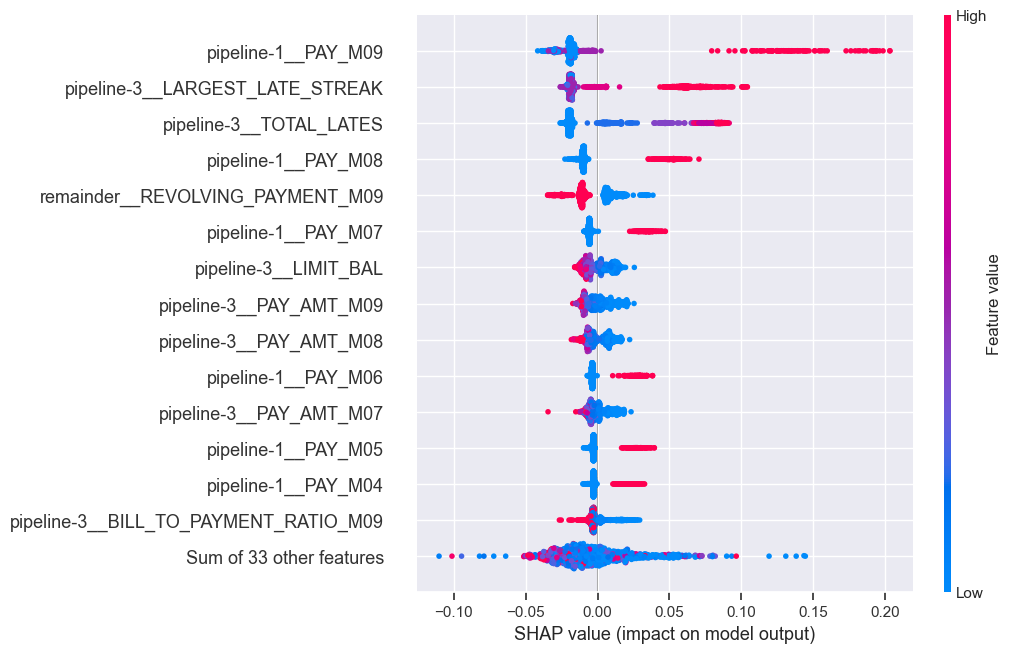

In [48]:
shap.plots.beeswarm(train_shap_values[:, :, 1], max_display=15)

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 12. Results on the test set
<hr>
Moment of truth!
</div>

### Findings
* We selected the tuned decision tree as the final model because it had a strong validation score and was much easier to interpret than the ensemble models. It was not the absolute highest-scoring model, but it was very close. Its cross-validation accuracy was 0.8187, and its final test accuracy was 0.8193.
* The test score is extremely close to the validation score. This is reassuring, since it suggests that the model's cross-validation performance was a good estimate of how it would perform on unseen data.
* We trust these results reasonably well because the test set was only used once at the end, and the validation/test accuracies are consistent. However, we still would not treat this as a perfect estimate of future real-world performance. The dataset comes from a specific setting, and real deployment data could be different.
* There is some risk of optimization bias. We tried many models, feature engineering choices, feature selection, and hyperparameter settings. Even though all of this was done using the training/CV scores and not the test set, repeatedly picking the best validation result can still make the validation score a little too optimistic.
* Interestingly, optimization bias does not seem too severe here, because the final test score is basically the same as the validation score.

### Individual prediction explanations

For the no-default example, the model predicted no default correctly, with a predicted probability of default of about 0.211. The SHAP plot shows that low/normal recent payment statuses, especially PAY_M09, pushed the prediction away from default. This makes sense because recent payment behaviour seems to be one of the strongest signals in this dataset. The total number of late payments also pushed the prediction downward. The main feature pushing the other way was PAY_AMT_M07, but it was not enough to change the final prediction.

For the default example, the model predicted default correctly, with a predicted probability of default of about 0.786. The most important reason was PAY_M09, which pushed the probability of default up by a lot. TOTAL_LATES also pushed strongly toward default, and PAY_M04 contributed a smaller amount in the same direction. This example had payment status values of 2 across all recent months, meaning the client was repeatedly late. So the model's prediction seems very reasonable and lines up with our earlier interpretation that recent repayment status is the most important group of features.f features.

In [49]:
from sklearn.metrics import accuracy_score

# Final selected model: tuned decision tree
chosen_dt_pipe = dt_search.best_estimator_
chosen_dt_pipe.fit(X_train, y_train)

y_test_pred = chosen_dt_pipe.predict(X_test)
y_test_proba = chosen_dt_pipe.predict_proba(X_test)[:, 1]

validation_score = dt_search.best_score_
test_score = accuracy_score(y_test, y_test_pred)

dt_test_results = pd.DataFrame(
    {
        "validation_accuracy": [validation_score],
        "test_accuracy": [test_score],
    },
    index=["decision_tree"],
)

dt_test_results

,validation_accuracy,test_accuracy
decision_tree,0.818667,0.819333


In [50]:
y_test_array = y_test.to_numpy()

no_default_candidates = np.where((y_test_array == 0) & (y_test_pred == 0))[0]
default_candidates = np.where((y_test_array == 1) & (y_test_pred == 1))[0]

no_default_ex_idx = no_default_candidates[0]
default_ex_idx = default_candidates[0]

no_default_ex_idx, default_ex_idx

(np.int64(0), np.int64(2))

In [51]:
X_test.iloc[no_default_ex_idx]

ID              25666.0
LIMIT_BAL       40000.0
SEX                 2.0
EDUCATION           2.0
MARRIAGE            2.0
AGE                26.0
PAY_M04             0.0
BILL_AMT_M04    18697.0
PAY_AMT_M04     10000.0
PAY_M05            -1.0
BILL_AMT_M05    44024.0
PAY_AMT_M05       680.0
PAY_M06             0.0
BILL_AMT_M06        0.0
PAY_AMT_M06     22373.0
PAY_M07             0.0
BILL_AMT_M07    13600.0
PAY_AMT_M07         0.0
PAY_M08             0.0
BILL_AMT_M08    24391.0
PAY_AMT_M08      1000.0
PAY_M09            -1.0
BILL_AMT_M09    28991.0
PAY_AMT_M09      1300.0
Name: 25665, dtype: float64

In [52]:
X_test.iloc[default_ex_idx]

ID               22387.0
LIMIT_BAL       170000.0
SEX                  2.0
EDUCATION            1.0
MARRIAGE             2.0
AGE                 30.0
PAY_M04              2.0
BILL_AMT_M04    170922.0
PAY_AMT_M04       1000.0
PAY_M05              2.0
BILL_AMT_M05    168094.0
PAY_AMT_M05       5500.0
PAY_M06              2.0
BILL_AMT_M06    157577.0
PAY_AMT_M06      13000.0
PAY_M07              2.0
BILL_AMT_M07    161487.0
PAY_AMT_M07          0.0
PAY_M08              2.0
BILL_AMT_M08    158819.0
PAY_AMT_M08       6500.0
PAY_M09              2.0
BILL_AMT_M09    155910.0
PAY_AMT_M09       6800.0
Name: 22386, dtype: float64

In [53]:
example_indices = [no_default_ex_idx, default_ex_idx]
example_names = ["no_default_example", "default_example"]

examples_df = X_test.iloc[example_indices].copy()

examples_df.insert(0, "example", example_names)

examples_df["actual"] = y_test.iloc[example_indices].to_numpy()
examples_df["predicted"] = y_test_pred[example_indices]
examples_df["predicted_probability_default"] = y_test_proba[example_indices]

examples_df

,example,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_M04,BILL_AMT_M04,PAY_AMT_M04,...,PAY_AMT_M07,PAY_M08,BILL_AMT_M08,PAY_AMT_M08,PAY_M09,BILL_AMT_M09,PAY_AMT_M09,actual,predicted,predicted_probability_default
25665,no_default_example,25666,40000.0,2,2,2,26,0,18697.0,10000.0,...,0.0,0,24391.0,1000.0,-1,28991.0,1300.0,0,0,0.210740
22386,default_example,22387,170000.0,2,1,2,30,2,170922.0,1000.0,...,0.0,2,158819.0,6500.0,2,155910.0,6800.0,1,1,0.786207


In [54]:
# Written with help from ChatGPT, prompt included asking it to seperate the processor and the final model so that the new features would still be added
# Separate preprocessing/feature engineering from the final model
preprocessor = chosen_dt_pipe[:-1]
dt_final_model = chosen_dt_pipe[-1]

X_test_transformed = preprocessor.transform(X_test)

if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

feature_names = preprocessor[-1].get_feature_names_out()

X_test_transformed_df = pd.DataFrame(
    X_test_transformed,
    columns=feature_names,
    index=X_test.index,
)

X_test_transformed_df.head()

,pipeline-1__PAY_M04,pipeline-1__PAY_M05,pipeline-1__PAY_M06,pipeline-1__PAY_M07,pipeline-1__PAY_M08,pipeline-1__PAY_M09,pipeline-2__AGE,pipeline-3__LIMIT_BAL,pipeline-3__BILL_AMT_M04,pipeline-3__PAY_AMT_M04,...,remainder__NO_ACTIVITY_M05,remainder__REVOLVING_PAYMENT_M05,remainder__NO_ACTIVITY_M06,remainder__REVOLVING_PAYMENT_M06,remainder__NO_ACTIVITY_M07,remainder__REVOLVING_PAYMENT_M07,remainder__NO_ACTIVITY_M08,remainder__REVOLVING_PAYMENT_M08,remainder__NO_ACTIVITY_M09,remainder__REVOLVING_PAYMENT_M09
25665,-0.315067,-0.310116,-0.337343,-0.382316,-0.396171,-0.468151,-1.034338,-0.982189,-0.336826,0.262869,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
16464,-0.315067,-0.310116,-0.337343,-0.382316,-0.396171,-0.468151,2.562302,-0.674969,0.179619,-0.178389,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
22386,2.489683,2.459362,2.294231,2.154380,2.102578,2.161560,-0.598381,0.016278,2.217873,-0.233918,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10149,-0.315067,-0.310116,-0.337343,-0.382316,-0.396171,-0.468151,0.600499,0.246693,-0.650606,-0.289117,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
8729,-0.315067,-0.310116,-0.337343,-0.382316,-0.396171,-0.468151,0.818477,-0.905384,-0.489210,-0.270901,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0


In [55]:
explainer = shap.TreeExplainer(dt_final_model)

# Pick two actual test rows
example_indices = [X_test.index[no_default_ex_idx], X_test.index[default_ex_idx]]
X_test_examples = X_test_transformed_df.loc[[X_test.index[no_default_ex_idx], X_test.index[default_ex_idx]]]

test_shap_values = explainer(X_test_examples)
X_test_examples

,pipeline-1__PAY_M04,pipeline-1__PAY_M05,pipeline-1__PAY_M06,pipeline-1__PAY_M07,pipeline-1__PAY_M08,pipeline-1__PAY_M09,pipeline-2__AGE,pipeline-3__LIMIT_BAL,pipeline-3__BILL_AMT_M04,pipeline-3__PAY_AMT_M04,...,remainder__NO_ACTIVITY_M05,remainder__REVOLVING_PAYMENT_M05,remainder__NO_ACTIVITY_M06,remainder__REVOLVING_PAYMENT_M06,remainder__NO_ACTIVITY_M07,remainder__REVOLVING_PAYMENT_M07,remainder__NO_ACTIVITY_M08,remainder__REVOLVING_PAYMENT_M08,remainder__NO_ACTIVITY_M09,remainder__REVOLVING_PAYMENT_M09
25665,-0.315067,-0.310116,-0.337343,-0.382316,-0.396171,-0.468151,-1.034338,-0.982189,-0.336826,0.262869,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
22386,2.489683,2.459362,2.294231,2.154380,2.102578,2.161560,-0.598381,0.016278,2.217873,-0.233918,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


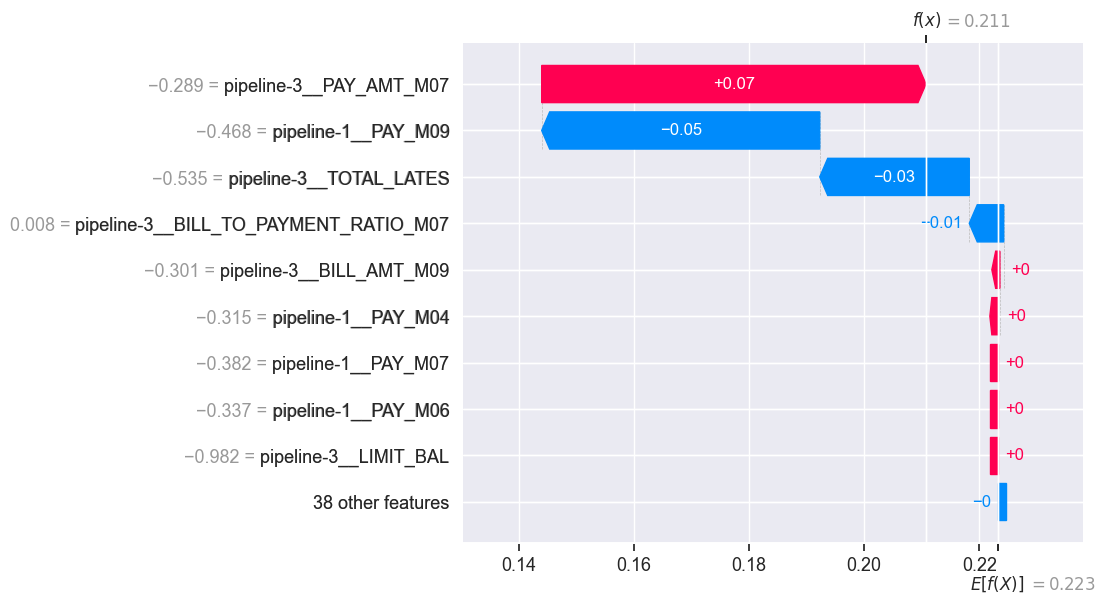

In [56]:
# Waterfall plot for no-default example
shap.plots.waterfall(test_shap_values[0, :, 1])

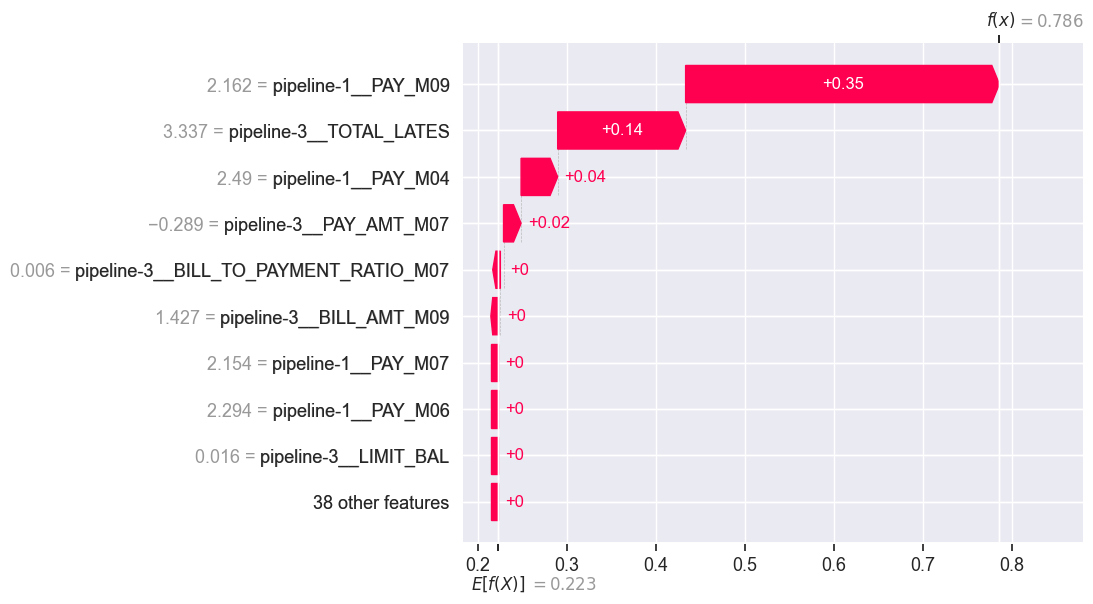

In [57]:
# Waterfall plot for default example
shap.plots.waterfall(test_shap_values[1, :, 1])

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 13. Summary of results
<hr>
</div>

### Concluding remarks

Overall, the models performed much closer to each other than we expected. The dummy classifier got around 77.7% accuracy, and most reasonable models ended up around 81-82% accuracy. This means the real improvement over the baseline was only about 4 percentage points. That is still meaningful, but it suggests that this dataset is difficult to classify with very high accuracy from these features.

The most useful features were the recent payment status features, especially for the most recent months. This makes sense: whether someone has recently been late is probably the clearest signal that they may default next month. Credit limit, bill amounts, payment amounts, and engineered features helped somewhat, but they did not dominate the model in the say. One surprising result was that more complicated models did not clearly crush the simpler ones. XGBoost had the highest tuned validation accuracy at about 82.1%, and random forest and gradient boosting were also strong. However, the tuned decision tree ended up very close, with about 81.9% validation accuracy. This is nice because the decision tree is much easier to interpret. The downside is that a single decision tree can be unstable, so we would be cautious about relying on it too much without more validation. Although XGBoost had the highest validation accuracy, we chose the decision tree as our final reported model because it gave a better balance between performance and interpretabiliy.
Feature selection was interesting because it showed that a smaller set of recent-payment and engineered features could preserve much of the performance for several models. However, it did not meaningfully improve the strongest models. For example, logistic regression stayed around 81.7-81.8%, and gradient boosting stayed around 81.9-82.0%. Because the reduced feature set did not clearly improve validation accuracy, we decided not to keep feature selection in the final pipeline.

### Future improvements

If we had more time, we would try a few more things:

* Use more evaluation metrics, especially recall, precision, F1 score, ROC AUC, and a confusion matrix. Accuracy is reasonable here because the dataset is not extremely imbalanced, but default is the more important class, so false negatives may be especially costly.
* Tune the classification threshold instead of using the default threshold of 0.5. In a credit default problem, the best threshold depends on the cost of missing a default versus incorrectly flagging a reliable client.
* Try more careful hyperparameter optimization for the ensemble models, especially random forest, gradient boosting, XGBoost, LightGBM, or CatBoost.
* Explore more domain-specific feature engineering, such as trends in bill amounts, trends in payment amounts, payment-to-bill ratios over time, and whether the client's financial situation is getting better or worse.
* Investigate interpretability more deeply using SHAP summary plots and individual explanations for more examples, especially false positives and false negatives.

### Final result

The final model we evaluated on the test set was the tuned decision tree. The final test accuracy was 0.8193, using accuracy as the evaluation metric. This is very close to the model's cross-validation accuracy of 0.8187, so the result seems fairly consistent with the validation experiments.tion experiments.

In [58]:
models_to_show = [
    "dummy",
    "logistic_regression",
    "decision_tree",
    "k_neighbours",
    "random_forest",
    "gradient_boosting",
    "xgboost",
]

summary_df = before_df.loc[models_to_show, ["test_score", "train_score"]].rename(
    columns={
        "test_score": "default_cv_accuracy",
        "train_score": "default_train_accuracy",
    }
)

summary_df["after_feature_selection_cv_accuracy"] = after_df["test_score"].reindex(
    models_to_show
)

summary_df["tuned_cv_accuracy"] = tuned_results["best_cv_score"].reindex(
    models_to_show
)

summary_df["tuned_cv_accuracy"] = summary_df["tuned_cv_accuracy"].apply(
    lambda x: f"{x:.3f}" if pd.notna(x) else ""
)

summary_df["final_test_accuracy"] = ""
summary_df.loc["decision_tree", "final_test_accuracy"] = f"{test_score:.3f}"


summary_df

,default_cv_accuracy,default_train_accuracy,after_feature_selection_cv_accuracy,tuned_cv_accuracy,final_test_accuracy
dummy,0.777 (+/- 0.000),0.777 (+/- 0.000),NaN,,
logistic_regression,0.818 (+/- 0.004),0.818 (+/- 0.001),0.817 (+/- 0.004),0.818,
decision_tree,0.723 (+/- 0.003),0.999 (+/- 0.000),0.749 (+/- 0.035),0.819,0.819
k_neighbours,0.795 (+/- 0.005),0.844 (+/- 0.002),0.798 (+/- 0.007),0.813,
random_forest,0.814 (+/- 0.007),0.999 (+/- 0.000),0.804 (+/- 0.011),0.819,
gradient_boosting,0.820 (+/- 0.006),0.828 (+/- 0.002),0.819 (+/- 0.004),0.819,
xgboost,0.810 (+/- 0.007),0.915 (+/- 0.003),0.810 (+/- 0.004),0.821,


<!-- END QUESTION -->

<br><br>

<br><br>

<!-- BEGIN QUESTION -->

## 14. Our takeaway
<hr>
</div>

There is no escaping human insight on the data. While the final supervised model is often the impressive part, the most important parts (EDA, feature engineering, meta-decisions) are always invisible. The best way to improve a model, aside from the obvious (e.g. hyperparameters), is to present the data better.

We saw this in our own project. The logistic regressor in part 7 scored almost 1.5% higher once we revisited EDA and engineered additional features... which is incredible! Without changing the model or turning a single dial, our model was making much fewer mistakes.

We saw the benefits of this invisible work again in feature selection. With only 4 engineered features and the performance of the 2 most recent months, we could train models 99% as effective as those that used the entire feature set. Perhaps with more EDA and feature engineering, we could achieve even better results.

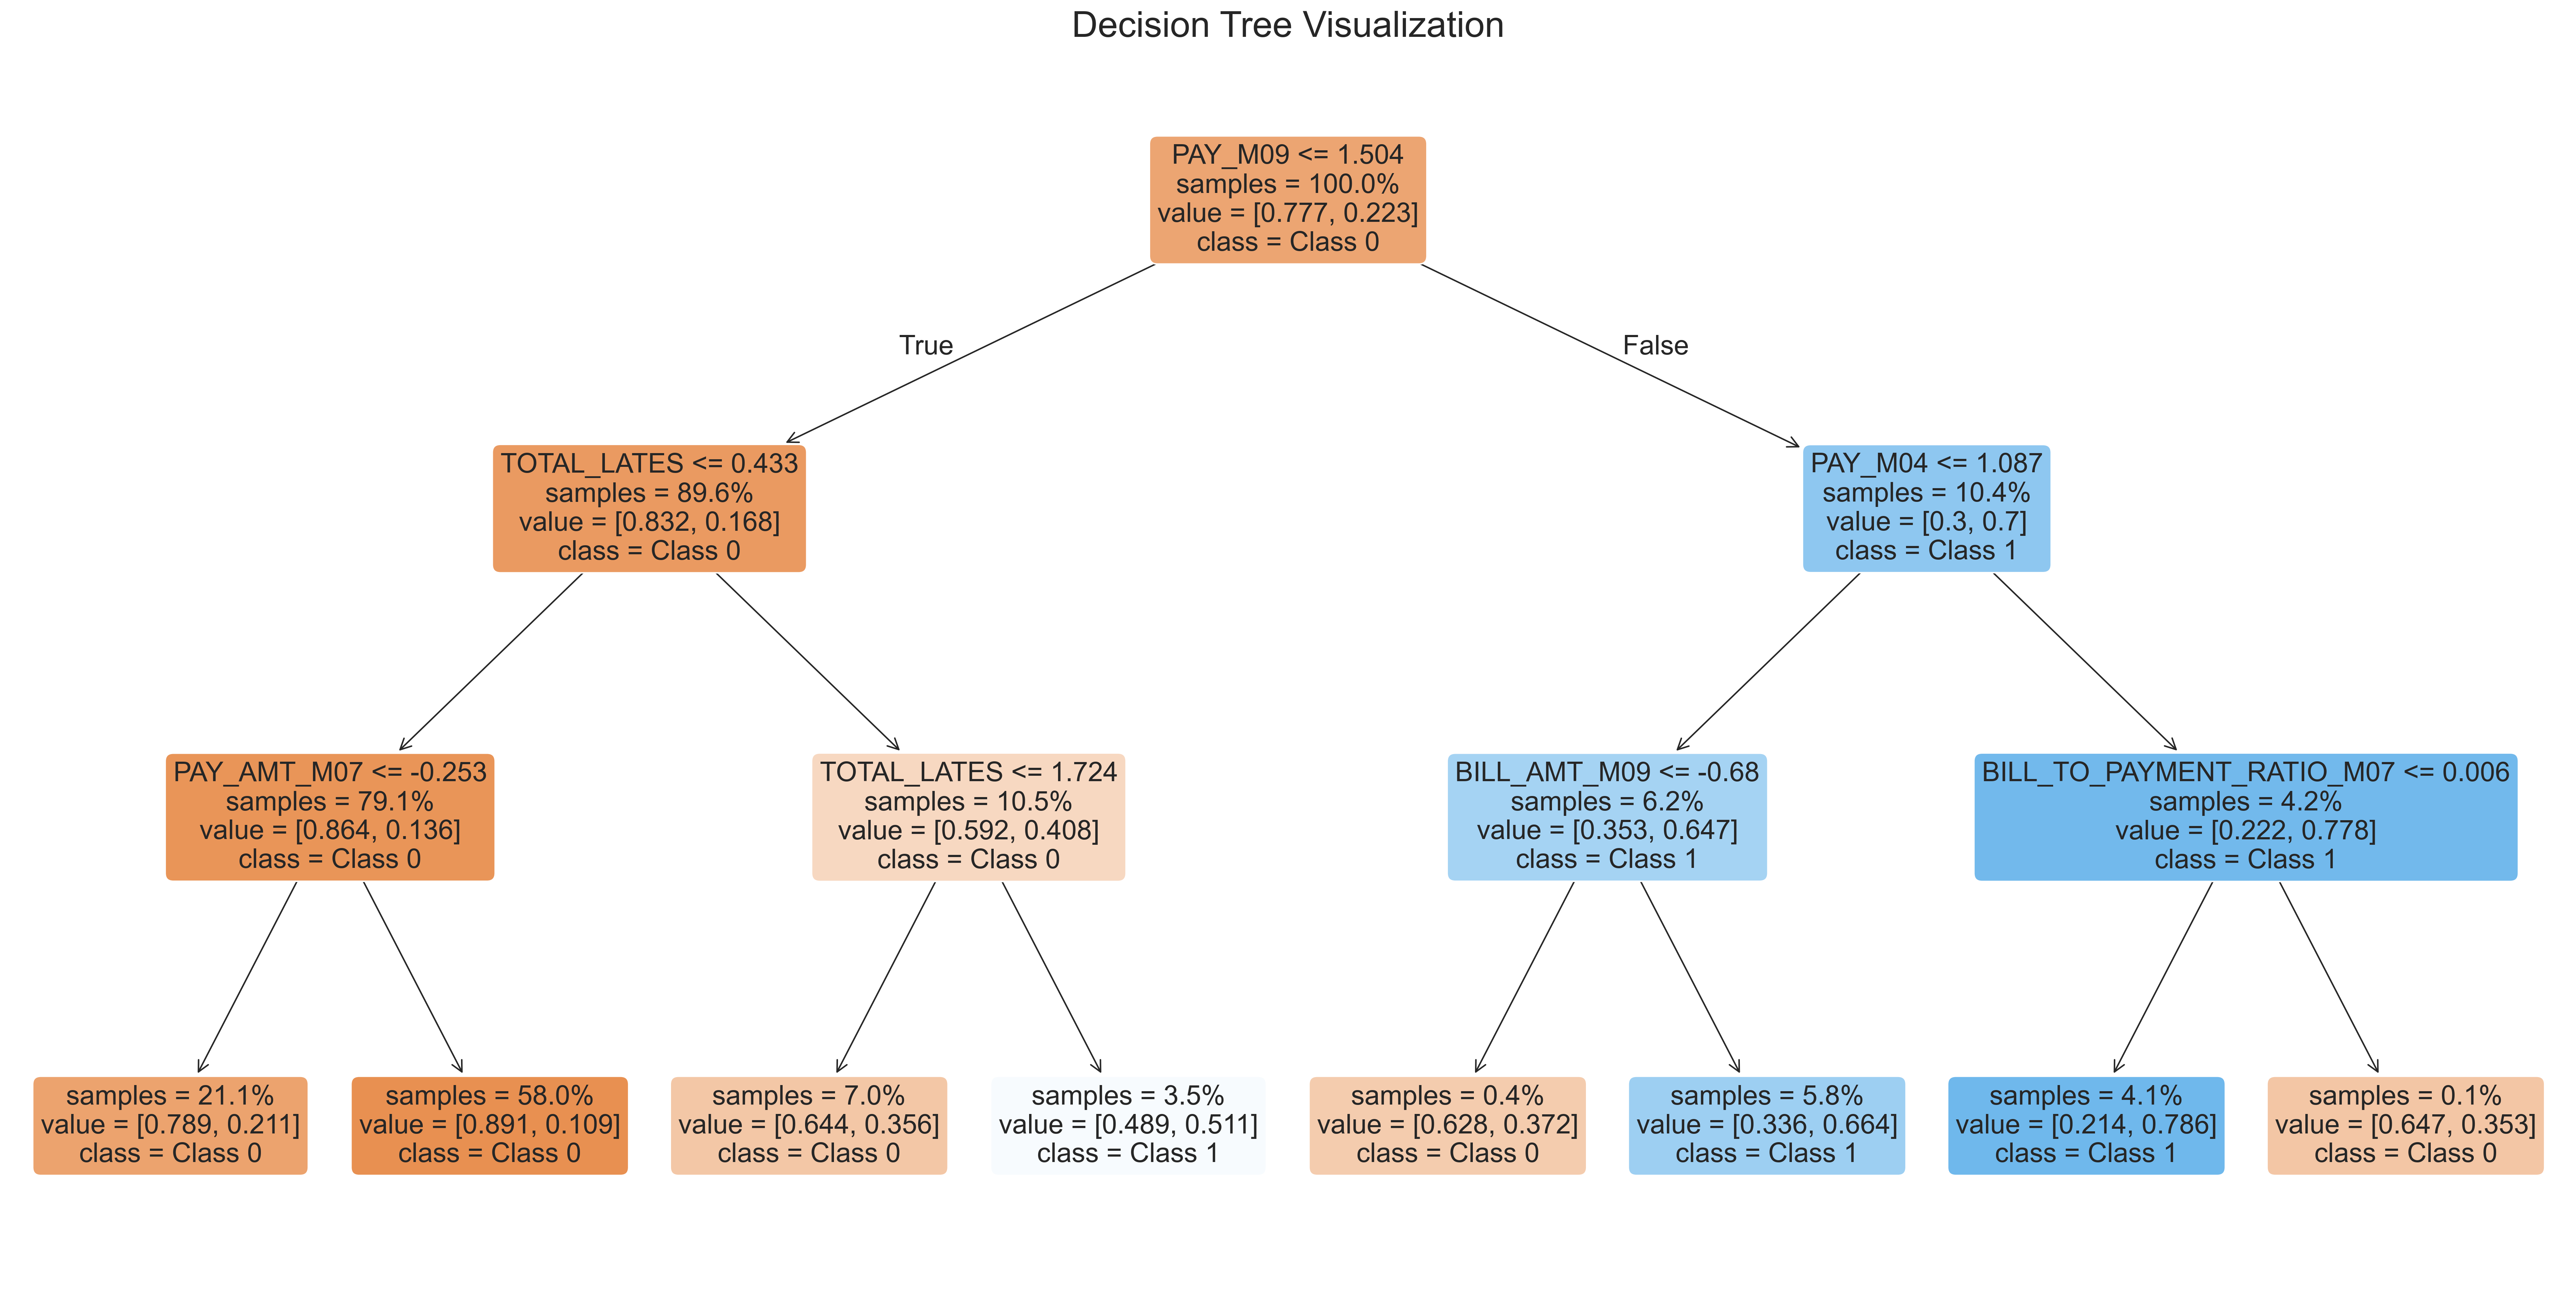

In [59]:
# Code by gemini to plot tree
# Code by gemini to plot tree
from sklearn.tree import plot_tree

# 1. Grab the decision tree
my_tree = chosen_dt_pipe.named_steps['decisiontreeclassifier']

# 2. Find the ColumnTransformer inside your pipeline
col_transformer = None
for step_name, step in chosen_dt_pipe.named_steps.items():
    if isinstance(step, ColumnTransformer):
        col_transformer = step
        break

# 3. BRUTE FORCE THE FEATURE NAMES
brute_force_names = []

# Loop through every chunk you built in your ColumnTransformer
for name, transformer, original_columns in col_transformer.transformers_:
    # Skip dropped columns
    if transformer == 'drop':
        continue
        
    ohe_found = False
    
    # Check if this specific pipeline has a OneHotEncoder inside it
    if hasattr(transformer, 'named_steps'):
        for step_name, step in transformer.named_steps.items():
            if isinstance(step, OneHotEncoder):
                # Ask the OHE for its newly generated column names (e.g., MARRIAGE_1, MARRIAGE_2)
                ohe_cols = step.get_feature_names_out(original_columns)
                brute_force_names.extend(ohe_cols)
                ohe_found = True
                break
                
    # If no OHE was found, the column count didn't change, so we just use the original names
    if not ohe_found:
        # Check to avoid adding indices if 'remainder'='passthrough' was used
        if isinstance(original_columns, list) and len(original_columns) > 0 and isinstance(original_columns[0], str):
            brute_force_names.extend(original_columns)

# 4. PLOT THE TREE
# Added dpi=300 to make the text incredibly crisp, even if you zoom in.
fig, ax = plt.subplots(figsize=(24, 12), dpi=300) 

plot_tree(
    my_tree, 
    filled=True,                     
    rounded=True,                    
    fontsize=18, # <--- Bumped up from 10 to 18! (Feel free to push to 20+ if needed)                    
    feature_names=brute_force_names, 
    class_names=['Class 0', 'Class 1'], 
    ax=ax,
    proportion=True,
    impurity=False # <--- Added this line to hide the Gini index!                 
)

# Increased title size so it doesn't look tiny next to the new cell fonts
plt.title("Decision Tree Visualization", fontsize=24) 
plt.tight_layout()